# Итоговый проект. Предсказание бестселлеров для торговой сети

## Problem Statement

В одной из торговых сетей, есть проблема, что продукт, который высылается в магазины, часто лежит на полках. Что означает, что могут совершаться ошибки в распределение товара. Одной из задач, в распределение продукта, является максимализация продаж в первые недели, после его поступления. 

Как специалисты DS мы будем решать задачу классификации, определяя, определяя, может ли быть продукт бестселлером в конкретной локализации или нет. 

На входе у нас есть несколько заранее подготовленных датасетов:

* Датасет `Train` - основные данные с целевой переменной. Все коммерческие показатели удаленны для предотвращения утечки данных. Целевая переменная - `Is_Bestseller` - сведетельствует, что товар являлся бестселлером в конретном магазине в первые дни после поступления, то есть респределение товара было выполнено верно.

* Датасет `Weather` - погодные данные, для всего периода наших наблюдений - нас интересует средняя погода за последний 7 дней в городах, в которых присутствуют магазины.

* Датасет `Cities` - Вспомогательный сет со списком городов, где есть магазины сети

* Датасет `Product_Info` - дополнительные признаки, описывающие товар.

Ход работы:

1. Знакомство с данными, сбор наших данных в единный датасет;

2. Очистка и предобработка данных;

3. Исследовательский анализ данных, визуализация распределений, анализ распределения классов;

4. Преобразования признаков;

5. Моделирование:

    * Построение моделей;
    * Настройка гиперпараметров;
    * Оценка моделей;

6. Сохранение модели и пайплайна.

In [1270]:
# Испортируем необходимые библиотеки

import pandas as pd
import numpy as np
import joblib

# Визуализации

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')

# Статистика

from scipy.stats import chi2_contingency, shapiro, mannwhitneyu

# Преобразование признаков

import category_encoders as ce
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# Машинное обучение

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold 
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, silhouette_score, confusion_matrix
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, precision_recall_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Pipiline

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from imblearn.pipeline import Pipeline

In [925]:
# Задаем константы

RANDOM_STATE = 42

## 1. Знакомство с данными

### 1.1 Загружаем данные

In [1161]:
# Загружаем основной датасет

data = pd.read_csv('data/train.csv')
data.head()

,Store_id,Category,Product_id,Current_Season,Actual_Price,Price_Status,StockAvailableU,StockUSalesFloor,StockUBackroom,StockinTransitU,StockInProgressU,StatusSale,StatusProductSmartphone,IsReplenBlocked,Date,First_Allocation_Date,Days_in_Store,Is_Bestseller
0,256,t-shirts_s_s,8799M-99X,AW 2023,"59,99",Regular,9,9,0,0,0,Sale,SALE_05.01.24,NO,2024-01-01,2023-12-12,20,0
1,327,jogging_tops,0237Y-59M,AW 2023,"129,99",Regular,8,8,0,0,0,Sale,SALE_08.02.24,NO,2024-01-01,2023-12-12,20,0
2,256,jogging_tops,6582Y-99X,AW 2023,"39,99",Clearance,3,3,0,0,0,Sale,SALE_11.01.24,NO,2024-01-01,2023-12-12,20,1
3,340,jogging_tops,0237Y-59M,AW 2023,"129,99",Regular,11,6,5,2,0,Sale,SALE_08.02.24,NO,2024-01-01,2023-12-12,20,0
4,340,jogging_tops,0237Y-84M,AW 2023,"129,99",Regular,10,6,4,2,0,Sale,SALE_25.01.24,NO,2024-01-01,2023-12-12,20,0


In [1233]:
# Загружаем датасет с погодными данными

weather_data = pd.read_csv('data/weather_data.csv')
weather_data.head()

,index,time,city,tavg,tavg_7d
0,12631,2023-05-22,ALBA IULIA,17.9,17.90
1,12632,2023-05-23,ALBA IULIA,18.0,17.95
2,12633,2023-05-24,ALBA IULIA,17.7,17.87
3,12634,2023-05-25,ALBA IULIA,19.9,18.38
4,12635,2023-05-26,ALBA IULIA,19.4,18.58


In [1234]:
# Загружаем датасет с информацией о городах

cities_data = pd.read_csv('data/cities.csv', sep=';')
cities_data.head()

,Store_id,Country,City,Store_Name
0,185,Romania,BUCHAREST,PH07
1,193,Romania,TIMISOARA,PH09
2,195,Romania,CONSTANTA,PH10
3,198,Romania,BUCHAREST,PH11
4,199,Romania,CRAIOVA,PH12


In [1248]:
# Загружаем датасет с продуктовыми признаками

product_data = pd.read_csv('data/product_info.csv', sep=';')
product_data.head()

,Product_Line,Price_Category,Product_Composition,Fashion_Level,Method,Product_id,Color_info,Product_Type,Product_Shape
0,BASIC,HIP,100%Cotton,Basic,Knitted,2864M-48X,48X GRAPE,RG - Regular,Round Neck
1,BASIC,HIP,100%Cotton,Basic,Knitted,2864M-80X,80X BEIGE,RG - Regular,Round Neck
2,BASIC,HIP,100%Cotton,Basic,Knitted,2864M-09X,09X LIGHT GREY,RG - Regular,Round Neck
3,BASIC,HIP,100%Cotton,Basic,Knitted,2864M-90X,90X DARK GREY,RG - Regular,Round Neck
4,BASIC,HIP,100%Cotton,Basic,Knitted,8951Q-02X,02X NUDE,BS - Basic,Regular


### 1.2 Объединение данных

In [1259]:
# Создаем функцию для объединения всех датасетов в один рабочий

def merge_datasets(data, cities_data, weather_data, product_data):
    """
    Функция для объединения всех датасетов в один рабочий.
    """
    
    # удаляем дубликаты в каждом датасете
    
    cities_data = cities_data.drop_duplicates(subset='Store_id')
    weather_data = weather_data.drop_duplicates(subset=['time', 'city'])
    product_data = product_data.drop_duplicates(subset='Product_id')
    
    return data.merge(
        cities_data, 
        on='Store_id', 
        how='left'
    ).merge(
        weather_data[['time', 'city', 'tavg_7d']], 
        left_on=['Date', 'City'], 
        right_on=['time', 'city'], 
        how='left'
    ).merge(
        product_data, 
        on='Product_id', 
        how='left'
    )

In [1212]:
print("Product_id dups:", product_data.duplicated(subset='Product_id').sum())
print("Store_id dups:", cities_data.duplicated(subset='Store_id').sum())
print("Weather dups:", weather_data.duplicated(subset=['time', 'city']).sum())

Product_id dups: 93
Store_id dups: 0
Weather dups: 0


In [1166]:
# Производим объединение датасетов

data = merge_datasets(data, cities_data, weather_data, product_data)

### 1.3 Первичный анализ данных

In [873]:
# Проверим структуру данных, какие признаки являются категориальными, а какие числовыми

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153788 entries, 0 to 153787
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store_id                 153788 non-null  int64  
 1   Category                 153788 non-null  object 
 2   Product_id               153788 non-null  object 
 3   Current_Season           153788 non-null  object 
 4   Actual_Price             153788 non-null  object 
 5   Price_Status             153788 non-null  object 
 6   StockAvailableU          153788 non-null  int64  
 7   StockUSalesFloor         153788 non-null  int64  
 8   StockUBackroom           153788 non-null  int64  
 9   StockinTransitU          153788 non-null  int64  
 10  StockInProgressU         153788 non-null  int64  
 11  StatusSale               153788 non-null  object 
 12  StatusProductSmartphone  62765 non-null   object 
 13  IsReplenBlocked          153788 non-null  object 
 14  Date

In [874]:
# Посчитаем количество пропусков в данных

cols_with_nulls = data.isnull().sum()
cols_with_nulls.sort_values(ascending=False).head(5)

StatusProductSmartphone    91023
Fashion_Level              84937
Store_id                       0
Is_Bestseller                  0
Product_Type                   0
dtype: int64

In [875]:
# Проверим детально признак StatusProductSmartphone, что в него входит

data['StatusProductSmartphone'].value_counts()

StatusProductSmartphone
SALE_24.12.23                        4349
VIP                                  3422
OUTLET_03.25                         2791
SALE_24.12.24                        2745
MSS_27.09.23                         2527
                                     ... 
SALE_12.02.25/CHECK LABEL               1
SALE_16.01.25/TO HIDE AW24/OUTLET       1
CONT. 237AA-00X /VIP                    1
CONT. 237AA-99X /VIP                    1
SALE_24.12.23/CONT. 9316T-99X           1
Name: count, Length: 254, dtype: int64

In [876]:
# Аналогично проверяем детально признак Fashion_Level

data['Fashion_Level'].value_counts()

Fashion_Level
Standard      26752
Floor Core    22295
Timeless      11112
Wall           4233
Wall Core      3291
Trend           636
Basic           526
Image             6
Name: count, dtype: int64

In [877]:
# Посчитаем процент пропусков для столбцов

fashion_col = data['Fashion_Level'].isnull().sum() / data.shape[0]
smartphone_col = data['StatusProductSmartphone'].isnull().sum() / data.shape[0]

print(f'Доля пустых значений в признаке Fashion_Level: {round(fashion_col,2)}')
print(f'Доля пустых значений в признаке StatusProductSmartphone: {round(smartphone_col,2)}')

Доля пустых значений в признаке Fashion_Level: 0.55
Доля пустых значений в признаке StatusProductSmartphone: 0.59


**Видно, что пропуски есть только в 2 признаках и их достаточно много: > 50%. Также после проверки значений, можно сказать, что эти признаки малоинформативны. Запомним этом и потом удалим их из наших данных**

In [878]:
# Изучим статистические характеристики для числовых признаков

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Store_id,153788.0,291.492405,77.674265,185.00,227.00,278.00,362.00,442.00
StockAvailableU,153788.0,10.185476,3.432392,-10.00,8.00,10.00,12.00,93.00
StockUSalesFloor,153788.0,7.635901,3.025952,0.00,6.00,8.00,10.00,47.00
StockUBackroom,153788.0,2.531875,3.428292,0.00,0.00,2.00,4.00,77.00
StockinTransitU,153788.0,1.174799,3.117397,0.00,0.00,0.00,1.00,67.00
StockInProgressU,153788.0,0.044964,0.561348,0.00,0.00,0.00,0.00,81.00
Days_in_Store,153788.0,11.533611,5.914328,0.00,6.00,13.00,17.00,20.00
Is_Bestseller,153788.0,0.180554,0.384649,0.00,0.00,0.00,0.00,1.00
tavg_7d,153788.0,15.087109,7.914884,-5.99,8.84,15.44,21.49,30.97


In [879]:
# Изучим характеристики для категориальных признаков

data.describe(include='object').T

,count,unique,top,freq
Category,153788,26,t-shirts_s_s,45576
Product_id,153788,3341,405EM-99J,150
Current_Season,153788,8,AW 2024,40806
Actual_Price,153788,30,"99,99",22214
Price_Status,153788,3,Regular,149868
StatusSale,153788,2,Nonsale,113115
StatusProductSmartphone,62765,254,SALE_24.12.23,4349
IsReplenBlocked,153788,2,NO,150250
Date,153788,105,2024-09-09,3271
First_Allocation_Date,153788,400,2024-04-30,4041


In [880]:
# Изучим глубже, как выглядят данные в категориальных признаках

columns_to_check = ['Category', 'Current_Season', 'Actual_Price', 'Price_Status', 'StatusSale', 'IsReplenBlocked', 'Product_Line', 'Price_Category', 'Method', 'Product_Type']

for col in columns_to_check:
    if col in data.columns:
        print(f"{col}: {list(data[col].dropna().unique())}")

Category: ['t-shirts_s_s', 'jogging_tops', 'shirts_l_s', 't-shirts_s_s_lic', 'sweaters', 'outer_jackets', 'coats', 't-shirts_l_s', 'trousers', 'jeans_jacket', 'jeans_trousers', 'jackets', 'trousers_knitted', 'shorts', 'shorts_knitted', 'shirts_s_s', 'polos', 'jeans_shorts', 'polos(NOT USED)', 'jeans_trou(NOT USED)', 'coats(NOT USED)', 'polar_fleecy', 'jackets(NOT USED)', 'shorts (NOT USED)', 'jeans_shor(NOT USED)', 'shorts_kni(NOT USED)']
Current_Season: ['AW 2023', 'SS 2024', 'AW 2024', 'SS 2022', 'SS 2025', 'AW 2025', 'AW 2022', 'SS 2023']
Actual_Price: ['59,99', '129,99', '39,99', '159,99', '69,99', '15,99', '89,99', '79,99', '99,99', '219,99', '249,99', '45,99', '329,99', '49,99', '139,99', '179,99', '119,99', '29,99', '169,99', '19,99', '199,99', '259,99', '449,99', '399,99', '189,99', '279,99', '149,99', '55,99', '349,99', '25,99']
Price_Status: ['Regular', 'Clearance', 'Special Price']
StatusSale: ['Sale', 'Nonsale']
IsReplenBlocked: ['NO', 'YES']
Product_Line: ['REGULAR', 'LICE

#### Как видим, часть признаков нуждается в преобработке:
1. Цена в формате строки;
2. Сезоны разбиты по годам, можем сократить их до зима/лето
3. В признаке Price_Category есть пропуски - заполним их
4. В признаках Product_Type и Product_Line есть повторы и подобные значения

### 1.4 Предобработка данных

In [1167]:
# Определим функцию для преобразования признака цены

def update_price(price):
    """Преобразует строку с ценой в число с плавающей запятой.

    Args:
        price (str): Строка, представляющая цену с запятой вместо точки.

    Returns:
        float: Цена в формате числа с плавающей запятой.
    """
    s = price.replace(',', '.')
    return float(s)

In [1168]:
# Определим функцию для преобразования признака категории

def update_category(df):
    """Преобразует значения в столбце 'Category' заменяя некоторые значения

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Category'.

    Returns:
        DataFrame: DataFrame с обновленным столбцом 'Category'.
    """
    
    df['Category'] = df['Category'].replace({
        'polos(NOT USED)' : 'polos',
        'jeans_trou(NOT USED)' : 'jeans_trousers',
        'coats(NOT USED)' : 'coats',
        'jackets(NOT USED)' : 'jackets',
        'shorts (NOT USED)' : 'shorts', 
        'jeans_shor(NOT USED)' : 'jeans_shorts',
        'shorts_kni(NOT USED)' : 'shorts_knitted'
    })
    
    return df

In [1169]:
# Определим функцию для преобразования признака ценовой категории

def update_price_category(df):
    """Преобразует значения в столбце 'Price_Category' заменяя пропущенные значения на моду по категориям.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Price_Category'.

    Returns:
        DateFrame: DataFrame с обновленным столбцом 'Price_Category', где пропущенные значения заменены на моду по категориям.
    """
    price_categories = ['HIP', 'MIP', 'LIP']
    
    # Считаем моду по каждой категории, используя только валидные значения
    
    mode_map = (
        df[df['Price_Category'].isin(price_categories)]
        .groupby('Category')['Price_Category']
        .agg(lambda x: x.mode().iloc[0])  
    )

    # Применяем замену по строкам
    
    df['Price_Category'] = df.apply(
        lambda row: row['Price_Category']
        if row['Price_Category'] in price_categories
        else mode_map.get(row['Category'], 'MIP'),  
        axis=1
    )
    
    return df

In [884]:
# Посмотрим на уникальные значения в столбце 'Product_Line' и их количество

print(data['Product_Line'].unique())
print(data['Product_Line'].value_counts())

['REGULAR' 'LICENCE' 'HOUSE UNIVERSAL' 'BASIC' 'CORE' 'URBAN YOUNG'
 'EVERYDAY YOUNG']
Product_Line
REGULAR            76361
EVERYDAY YOUNG     23384
CORE               22940
BASIC              12998
LICENCE             9120
URBAN YOUNG         8380
HOUSE UNIVERSAL      605
Name: count, dtype: int64


In [1170]:
# Определим функцию для преобразования признака продуктовой линии

def update_product_line(df):
    """Объединяет некоторые значения в столбце 'Product_Line' в более общие категории.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Product_Line'.

    Returns:
        DataFrame: DataFrame с обновленным столбцом 'Product_Line', где некоторые значения заменены на более общие категории.
    """

    df['Product_Line'] = df['Product_Line'].replace({
        'HOUSE UNIVERSAL' : 'CORE',
        'URBAN YOUNG' : 'EVERYDAY YOUNG'
    })
    
    return df

In [886]:
# Посмотрим на уникальные значения в столбце 'Product_Type' и их количество

print(data['Product_Type'].unique())
print(data['Product_Type'].value_counts())

['RG - Regular' 'LC - Licence' 'LR - Licence Ready' 'TP - To Be Printed'
 'BS - Basic' 'TE – Test' 'DC - Dress Code']
Product_Type
RG - Regular          136085
LR - Licence Ready      6919
LC - Licence            5026
TP - To Be Printed      3636
BS - Basic              2000
TE – Test                120
DC - Dress Code            2
Name: count, dtype: int64


In [1257]:
# Определим функцию для преобразования признака продуктового типа

def update_product_type(df):
    """Объединяет некоторые значения в столбце 'Product_Type' в более общие категории. Отфильтровывает значения, которые не относятся к продукту (например, Dress Code).

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Product_Type'.

    Returns:
        DataFrame: DataFrame с обновленным столбцом 'Product_Type', где некоторые значения заменены на более общие категории.
    """
    df['Product_Type'] = df['Product_Type'].replace({
        'LR - Licence Ready' : 'LC - Licence',
        'TP - To Be Printed' : 'RG - Regular',
        'BS - Basic' : 'RG - Regular',
        'TE – Test' : 'RG - Regular',
        'DC - Dress Code' : 'RG - Regular'
    })
    
    return df

In [888]:
# Посмотрим на уникальные значения в столбце 'Product_Shape' и их количество

print(data['Product_Shape'].unique())
print(data['Product_Shape'].value_counts().head(20))

['Regular' 'Loose Fit' '[nieoznaczony]' 'Slim' 'Loose Long' 'Loose'
 'Relaxed' 'Regular Fit' 'Chino' 'Wide Leg' 'Straight' 'Carrot' 'Jogger'
 'Skater' 'Skinny' 'Super Slim' 'Other' 'Oversize' 'Sleeveless' 'Boxy'
 'Jorts' 'Round Neck' 'Cropped' 'Super Baggy' 'Baggy' 'Bombka'
 'Raglan Sleeve' 'Zipper' 'Joggers' 'Parachute' 'Dropped Sleeve' 'Hoodie'
 'Slim Fit' 'Carpenter' 'Carrots' 'Stand Up Collar' 'Short' 'Shorts'
 'Regular Waist' 'Quilted' 'Crew Neck' 'Relaxed Fit' 'Super Skinny'
 'V-neck' 'Denim Jacket' 'Vest' 'Cargo' 'Collar' 'Twisted Collar' 'Bomber'
 'Parka']
Product_Shape
Regular Fit       31385
Loose             28974
[nieoznaczony]    16400
Regular            8668
Boxy               8107
Slim               8085
Relaxed            7033
Jogger             5613
Cropped            4750
Oversize           3309
Loose Long         3268
Wide Leg           2811
Other              2717
Carrot             2506
Skater             2502
Straight           2448
Loose Fit          2184
Round N

**Как видим, достаточно много шейпов пересекается, попробуем объеденить часть из них**

In [1172]:
# Определим функцию для преобразования признака продуктового шейпа

def update_shape(df):
    """Преобразует значения в столбце 'Product_Shape', объеденяя некоторые значения на подобные категории и заполняя пропуски.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Product_Shape'.

    Returns:
        DataFrame: DataFrame с обновленным столбцом 'Product_Shape', где некоторые значения заменены на более общие категории и пропуски заполнены модой по категориям.
    """
    # Задаем словарь для замены значений в столбце 'Product_Shape' и заменяем их на подобные категории
    
    shape_mapping = {
        'Loose Fit': 'Loose',
        'Loose Long': 'Loose',
        'Relaxed Fit': 'Relaxed',
        'Regular Fit': 'Regular',
        'Regular Waist': 'Regular',
        'Slim Fit': 'Slim',
        'Super Slim': 'Slim',
        'Joggers': 'Jogger',
        'Carrots': 'Carrot',
        'Short': 'Shorts',
        '[nieoznaczony]': 'Other',
        'Super Baggy': 'Baggy',
        'Round Neck': 'Crew Neck',
        'Stand Up Collar': 'Collar',
        'Twisted Collar': 'Collar'
    }

    df['Product_Shape'] = df['Product_Shape'].replace(shape_mapping)

    # Заполняем 'Other' на моду внутри каждой категории
    
    mode_map = (
        df[df['Product_Shape'] != 'Other']
        .groupby('Category')['Product_Shape']
        .agg(lambda x: x.mode().iloc[0])
    )

    # Применяем замену для 'Other'
    
    def fill_other(row):
        """_summary_
        Функция для заполнения пропусков в столбце 'Product_Shape' на основе мода по категориям.
        """
        if row['Product_Shape'] == 'Other':
            return mode_map.get(row['Category'], 'Regular')
        return row['Product_Shape']

    df['Product_Shape'] = df.apply(fill_other, axis=1)

    return df

In [890]:
# Посмотрим на уникальные значения в столбце 'Product_Composition' и их количество

print(data['Product_Composition'].unique())
print(data['Product_Composition'].value_counts().head(20))

['100%Cotton' '60%Cotton, 40%Polyester'
 '53%Acrylic, 23%Polyester, 16%Polyamide, 8%Wool'
 '50%Viscose, 28%Polyester, 22%Polyamide' '100%Polyester' '100%Polyamide'
 '50%Cotton, 50%Polyester' '76%Polyester, 20%Viscose, 4%Elastane'
 '98%Cotton, 2%Elastane' '65%Polyester, 33%Viscose, 2%Elastane'
 '76%Polyester, 15%Viscose, 9%Elastane' '99%Cotton, 1%Elastane'
 '83%Cotton, 15%Polyester, 2%Elastane' '60%Polyester, 40%Viscose'
 '85%Cotton, 15%Linen' '88%Cotton, 12%Linen'
 '68%Cotton, 29%Polyamide, 3%Elastane'
 '66%Cotton, 31%Polyester, 3%Elastane'
 '80%Cotton, 18%Polyester, 2%Elastane' '75%Viscose, 25%Linen'
 '80%Cotton, 20%Polyester' '100%Viscose' '65%Polyester, 35%Cotton'
 '55%Cotton, 45%Polyamide' '80%Polyester, 18%Cotton, 2%Viscose'
 '55%Linen, 45%Cotton' '66%Cotton, 34%Polyester'
 '74%Cotton, 25%Polyester, 1%Elastane' '76%Viscose, 16%Cotton, 8%Linen'
 '46%Cotton, 46%Polyester, 8%Elastane'
 '48%Cotton, 48%Polyester, 4%Elastane' '93%Polyester, 7%Elastane'
 '56%Cotton, 43%Polyester, 1%Elast

**Видим огромное количество разных сочетаний тканей и материалов. Попробуем выделить основые ткани и создадим новый признак. Если главной ткани есть 90 и больше процентов, то будем означать ее как отдельный материал из которого состоит продукт. Если меньше, будем доабавлять приставку микс**

In [1173]:
# Определим функцию для преобразования признака составка продукта

def extract_main_fabric(composition_str):
    """ Извлекает основной материал из строки состава продукта

    Args:
        composition_str (str): Строка, представляющая состав продукта

    Returns:
        str: Основной материал или 'Unknown', если не удалось распознать состав
    """
    try:
        # Разбиваем строку на части вида "XX%Material"
        
        parts = composition_str.split(',')
        parsed = []

        for part in parts:
            part = part.strip()
            if '%' in part:
                percent, material = part.split('%')
                parsed.append((int(percent), material.strip()))
        
        # Сортируем по убыванию процента
        
        parsed.sort(reverse=True)

        if parsed[0][0] >= 90:
            return parsed[0][1]  # чистый материал
        else:
            return parsed[0][1] + '_mix'  # основа + примесь
    except Exception as e:
        print(f"[WARN] Couldn't parse: {composition_str}. Error: {e}")
        return 'Unknown'

In [892]:
print(data['Current_Season'].unique())

['AW 2023' 'SS 2024' 'AW 2024' 'SS 2022' 'SS 2025' 'AW 2025' 'AW 2022'
 'SS 2023']


In [1174]:
# Определим функцию для преобразования признака сезонности

def update_season(df):
    """ Преобразует значения в столбце 'Current_Season', объединяя их в две категории: 'AW' (осень-зима) и 'SS' (весна-лето).

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Current_Season'.

    Returns:
        DataFrame: DataFrame с обновленным столбцом 'Current_Season', где значения заменены на 'AW' или 'SS'.
    """
    df['Current_Season'] = df['Current_Season'].apply(lambda x: 'AW' if x.split(' ')[0] == 'AW' else 'SS')
    return df


In [1175]:
# Применяем функции для преобразования признаков

data = update_category(data)
data = update_price_category(data)
data = update_product_line(data)
data = update_product_type(data)
data = update_shape(data)
data = update_season(data)
data['Actual_Price'] = data['Actual_Price'].apply(update_price)
data['Main_Fabric'] = data['Product_Composition'].apply(extract_main_fabric)           

## 2. Исследовательский анализ данных (EDA)

### 2.1 Изучим распределение классов

In [895]:
data['Is_Bestseller'].value_counts(normalize=True)

Is_Bestseller
0    0.819444
1    0.180556
Name: proportion, dtype: float64

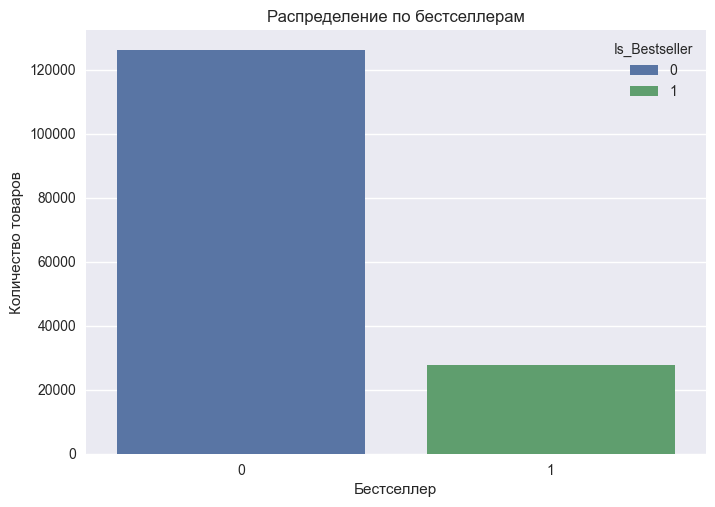

In [896]:
bardata = data.groupby('Is_Bestseller', as_index=False)['Product_id'].count()

sns.barplot(bardata, x='Is_Bestseller', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по бестселлерам')
plt.xlabel('Бестселлер')
plt.ylabel('Количество товаров')
plt.show();

**Есть сильный дисбаланс в сторону класса 0**

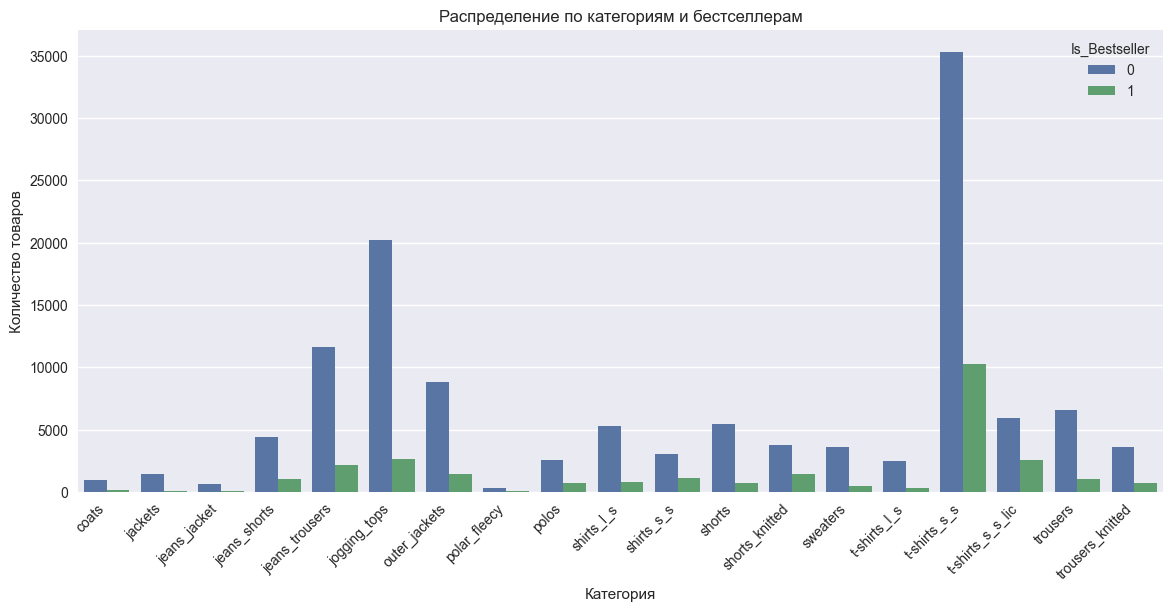

In [897]:
# Посмотрим на распределение по категориям и бестселлерам

bardata = data.groupby(['Category', 'Is_Bestseller'], as_index=False)['Product_id'].count()

fig = plt.figure(figsize=(14,6))
sns.barplot(data=bardata, x='Category', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по категориям и бестселлерам')
plt.xlabel('Категория')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.show();

**Видим, что большое количество бестселлеров у нас приходится на футболки с коротким рукавом, однако также это в принципе самая насыщенная категория. Также есть еще несколько категорий, где количество бестселлеров суммарно достигает несколько тысяч**

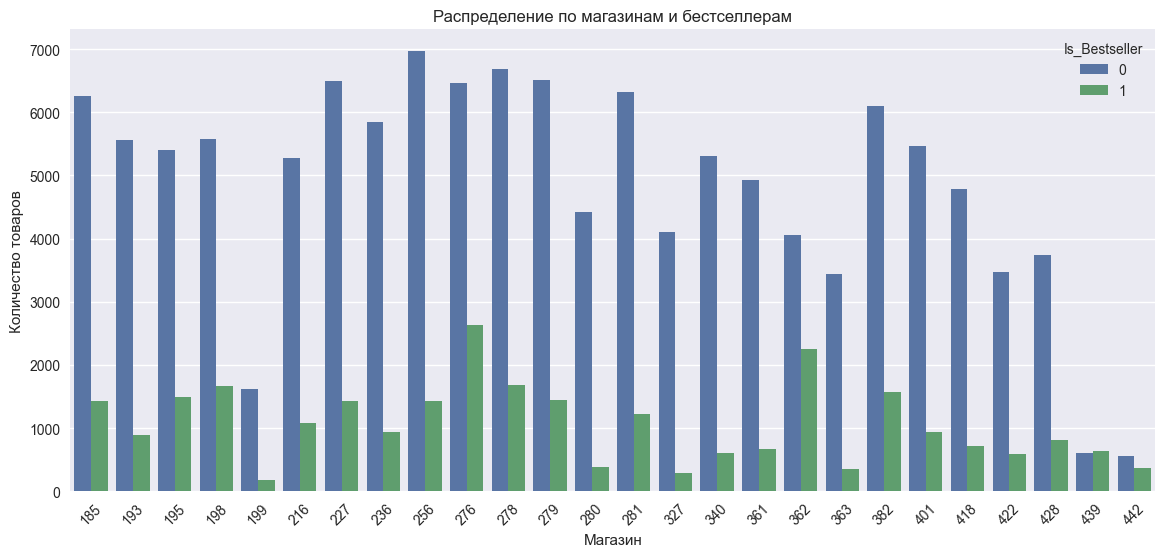

In [898]:
# Посмотрим на распределение бестселлеров по магазинам

bardata = data.groupby(['Store_id', 'Is_Bestseller'], as_index=False)['Product_id'].count()

fig = plt.figure(figsize=(14,6))
sns.barplot(data=bardata, x='Store_id', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по магазинам и бестселлерам')
plt.xlabel('Магазин')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45)
plt.show();

**Видим, что в 2х магазинах доля бестселлеров достаточно большая (276 и 362) - будем считать их за топ-магазины, в некоторых магазинах доля совсем низкая (199, 280, 327, 363), слабые магазины. Остальные магазины можем назвать середняки**

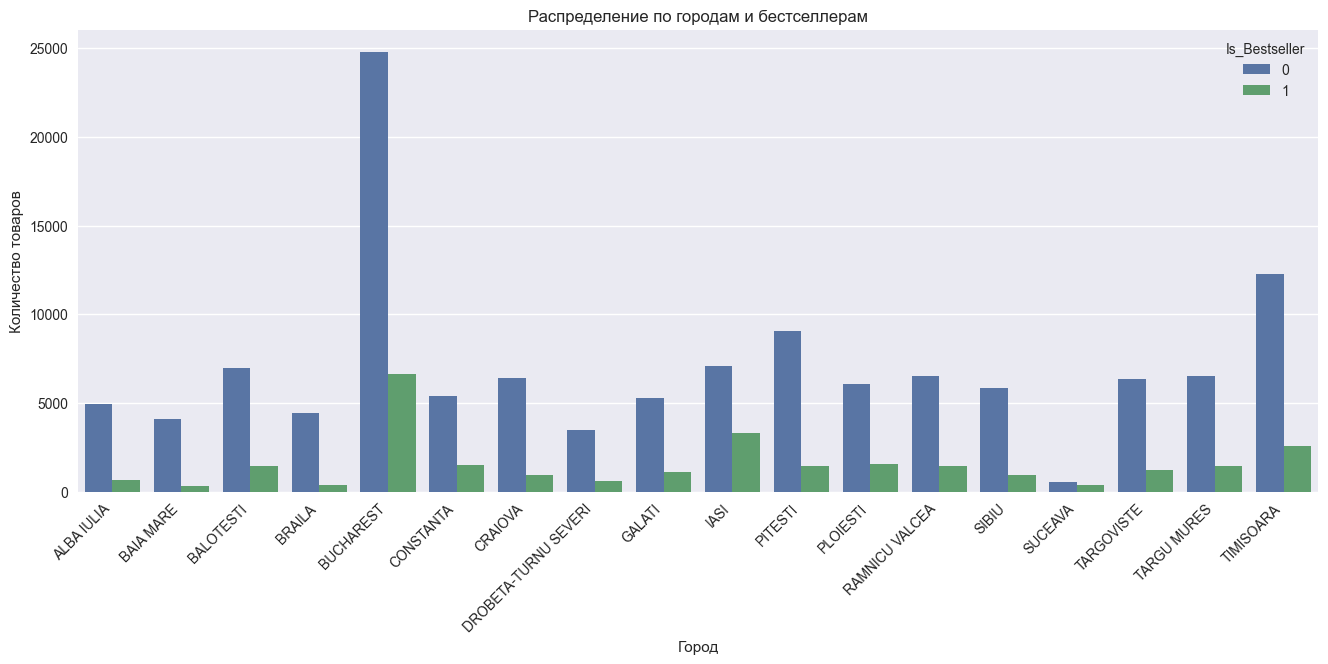

In [899]:
# Посмотрим на распределение бестселлеров по городам

bardata = data.groupby(['City', 'Is_Bestseller'], as_index=False)['Product_id'].count()

fig = plt.figure(figsize=(16,6))
sns.barplot(data=bardata, x='City', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по городам и бестселлерам')
plt.xlabel('Город')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.show();

**Явно выделяются 3 города - Бухарест, Яссы, Тимишоара**

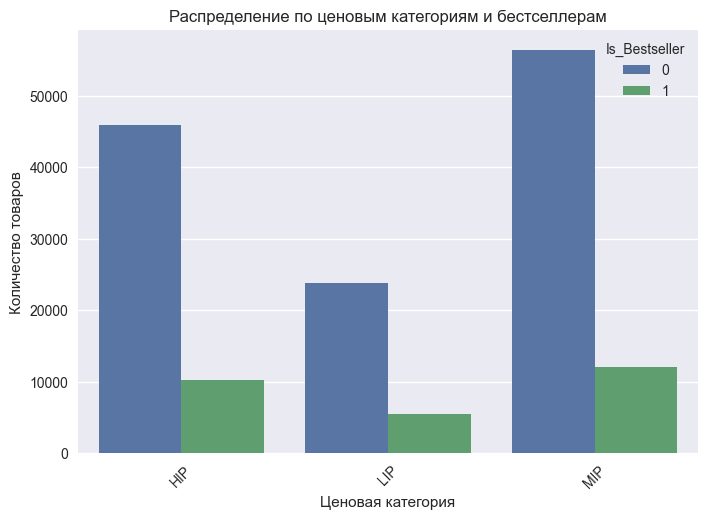

In [900]:
# Посмотрим на распределение бестселлеров по ценовым категориям

bardata = data.groupby(['Price_Category', 'Is_Bestseller'], as_index=False)['Product_id'].count()

sns.barplot(data=bardata, x='Price_Category', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по ценовым категориям и бестселлерам')
plt.xlabel('Ценовая категория')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45)
plt.show();

**В целом распределение ровное, однако средний ценовой сегмент немного выбивается**

### 2.2 Изучим влияние временного фактора

In [1176]:
# Определим функцию для добавления временных признаков

def add_datetime_features(df):
    """Добавляет временные признаки в DataFrame, включая год, месяц и номер недели.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Date'.

    Returns:
        DataFrame: DataFrame с добавленными временными признаками.
    """
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week_Number'] = pd.to_datetime(df['Date']).dt.isocalendar().week
    
    return df

In [1177]:
# Применяем функцию для добавления временных признаков

data = add_datetime_features(data)

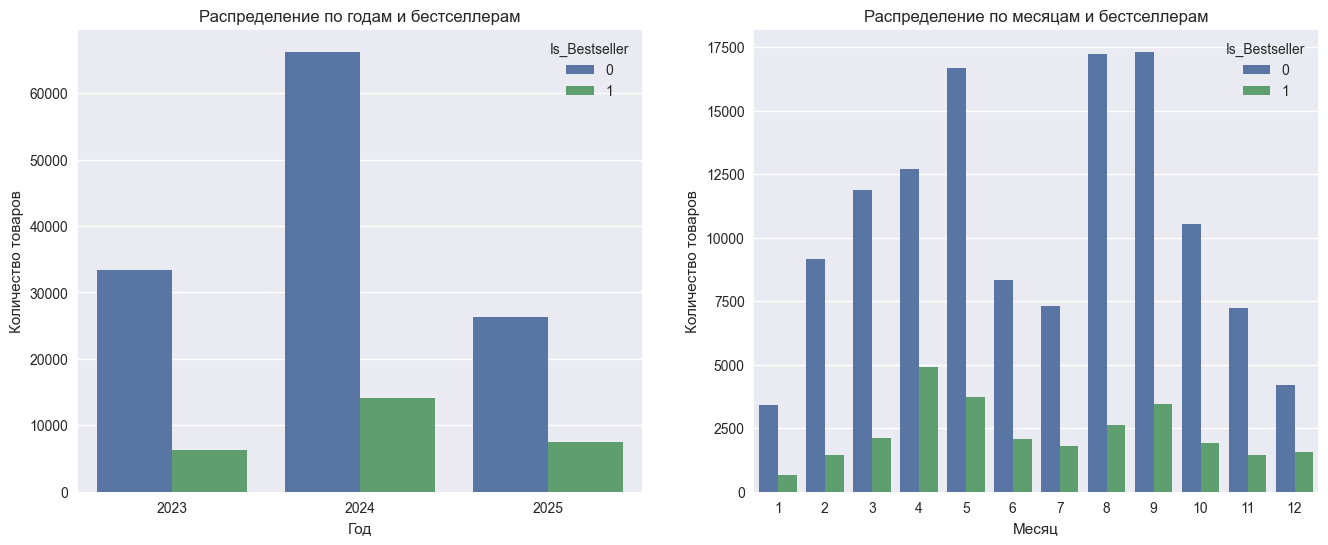

In [902]:
# Посмотрим на распределение бестселлеров по годам и месяцам

yeardata = data.groupby(['Year', 'Is_Bestseller'], as_index=False)['Product_id'].count()
monthdata = data.groupby(['Month', 'Is_Bestseller'], as_index=False)['Product_id'].count()

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(16,6))
sns.barplot(data=yeardata, x='Year', y='Product_id', hue='Is_Bestseller', ax=ax[0])
sns.barplot(data=monthdata, x='Month', y='Product_id', hue='Is_Bestseller', ax=ax[1])
ax[0].set_title('Распределение по годам и бестселлерам')
ax[0].set_xlabel('Год')
ax[0].set_ylabel('Количество товаров')
ax[1].set_title('Распределение по месяцам и бестселлерам')
ax[1].set_xlabel('Месяц')
ax[1].set_ylabel('Количество товаров')
plt.show();


**Видим, что расрпеделение по годам неравномерное, однако это связано с тем, что наши данные собраны с середины 2023 года по середину 2025 года. Данный признак нам будет неинформативен.
В распределение по месяцам, видно, что есть месяца на которые приходится больше бестселлеров, чем на другие. Например Апрель и Сентябрь явно выделяются. Также есть откровенно слабые месяца, такие как Январь**

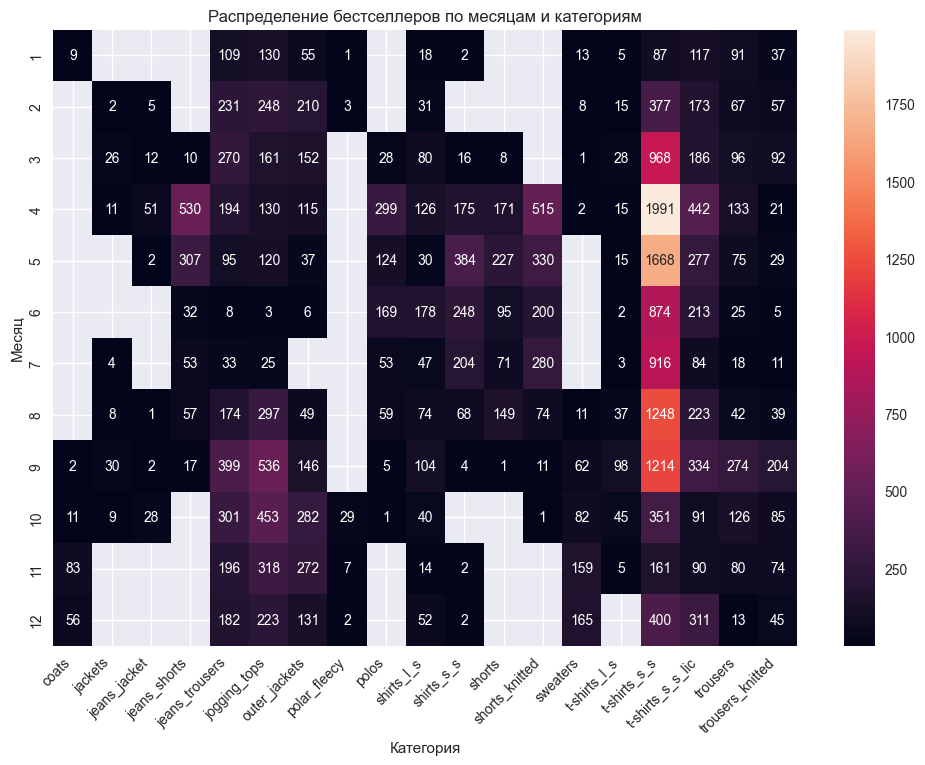

In [903]:
# Посмотрим на распределение бестселлеров по месяцам и категориям

pivot_data = data[data['Is_Bestseller'] == 1]

pt = pd.pivot_table(
    pivot_data,
    values='Product_id',
    index='Month', 
    columns='Category',
    aggfunc='count'
)

fig = plt.figure(figsize=(12,8))
sns.heatmap(pt, annot=True, fmt='.0f')
plt.title('Распределение бестселлеров по месяцам и категориям')
plt.xlabel('Категория')
plt.ylabel('Месяц')
plt.xticks(rotation=45, ha='right')
plt.show();

**Видим, что футболки доминиуруют в количестве бестселлеров, однако и другие категории также имеют своим пики продаж в определенные месяцы. Например джинсы и толстовки проявляют себя лучше в осенние месяцы, а зимние или летние категории в целом продаются только в течение пары месяцев**

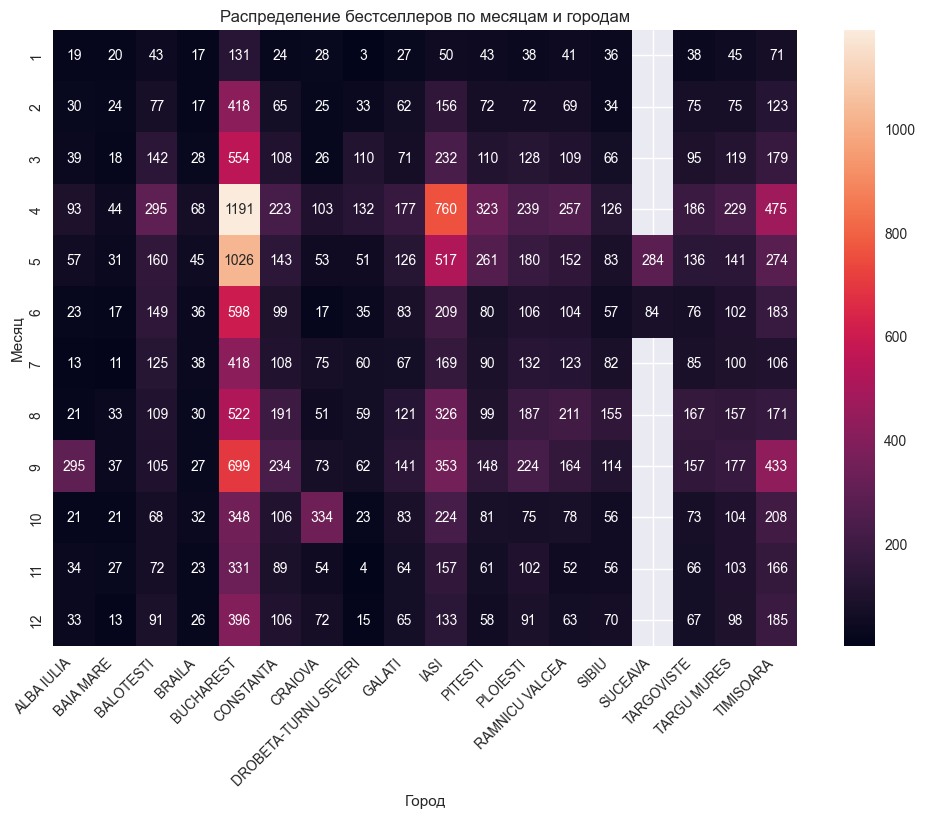

In [904]:
# Посмотрим на распределение бестселлеров по месяцам и городам

pivot_data = data[data['Is_Bestseller'] == 1]

pt = pd.pivot_table(
    pivot_data,
    values='Product_id',
    index='Month', 
    columns='City',
    aggfunc='count'
)

fig = plt.figure(figsize=(12,8))
sns.heatmap(pt, annot=True, fmt='.0f')
plt.title('Распределение бестселлеров по месяцам и городам')
plt.xlabel('Город')
plt.ylabel('Месяц')
plt.xticks(rotation=45, ha='right')
plt.show();

**Тут наши предыдущие выводы аналогично повторяются. Однако отдельно стоит отметить, что для города Сучава есть данные только для 2 месяцов. Магазин только открылся, поэтому его в дальнейшем исключим из данных**

### 2.3 Посмотрим взаимосвязи между бестселлерами и продуктовыми признаками

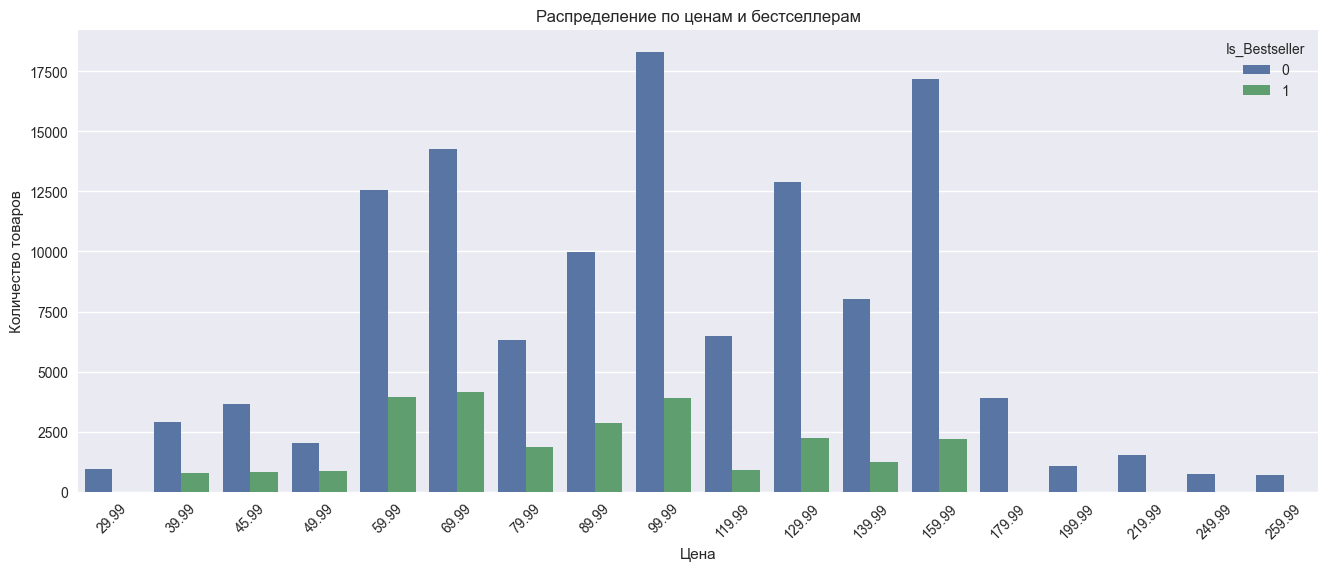

In [905]:
# Посмотрим на распределение бестселлеров по ценам

bardata = data.groupby(['Actual_Price', 'Is_Bestseller'], as_index=False)['Product_id'].count().sort_values(by='Product_id', ascending=False).head(30)

fig = plt.figure(figsize=(16,6))
sns.barplot(data=bardata, x='Actual_Price', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по ценам и бестселлерам')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45)
plt.show();

**Видно, что товары, которые стоят `59.99`, `69.99`, `89.99`, `99.99` явно имеют большую вероятность стать бестселлером, чем остальные. Товары из догогого сегмента непользуются популярностью, товары из среднего в целом ок, но их доля меньше**

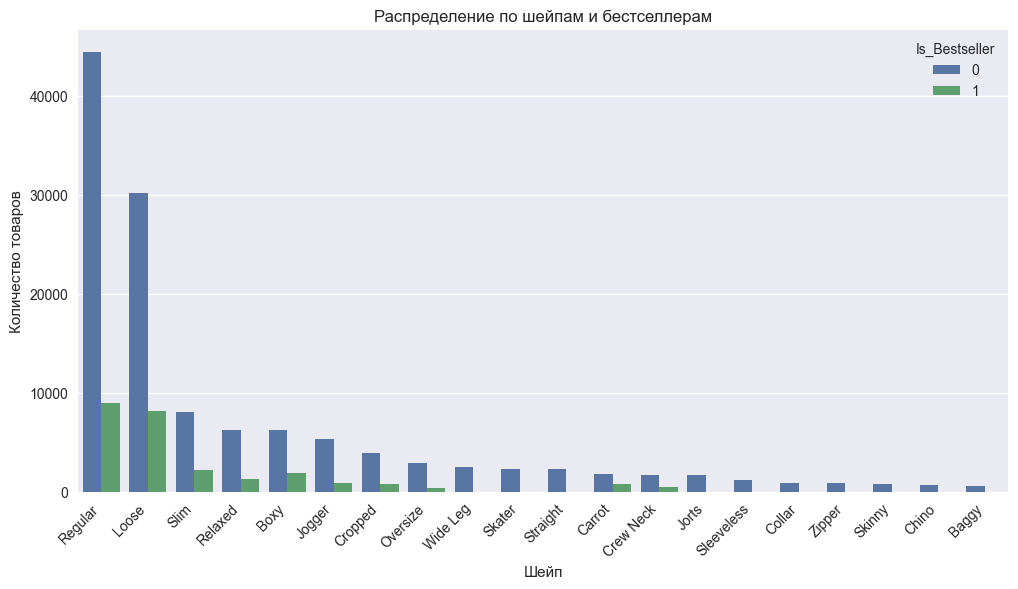

In [906]:
# Посмотрим на распределение бестселлеров по шейпам

bardata = data.groupby(['Product_Shape', 'Is_Bestseller'], as_index=False)['Product_id'].count().sort_values(by='Product_id', ascending=False).head(30)

fig = plt.figure(figsize=(12,6))
sns.barplot(data=bardata, x='Product_Shape', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по шейпам и бестселлерам')
plt.xlabel('Шейп')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.show();

**Из графика видно, что шейпы Regular и Loose сильнее всего выбиваются из общие массы**

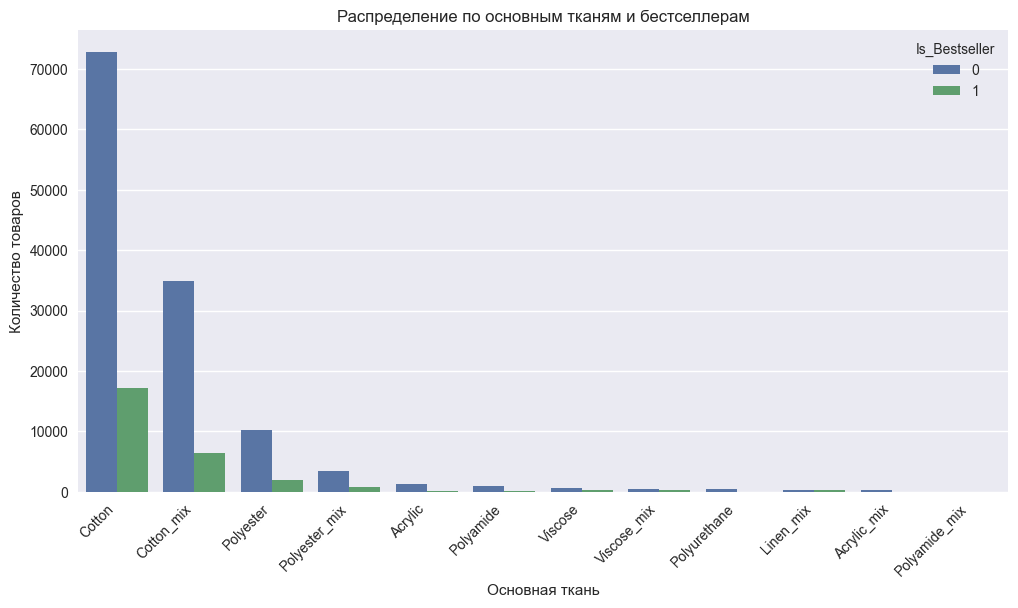

In [907]:
# Посмотрим на распределение бестселлеров по основным тканям

bardata = data.groupby(['Main_Fabric', 'Is_Bestseller'], as_index=False)['Product_id'].count().sort_values(by='Product_id', ascending=False).head(30)

fig = plt.figure(figsize=(12,6))
sns.barplot(data=bardata, x='Main_Fabric', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по основным тканям и бестселлерам')
plt.xlabel('Основная ткань')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.show();

**Товары из хлопка или хлопка с домешкой продаются лучше**

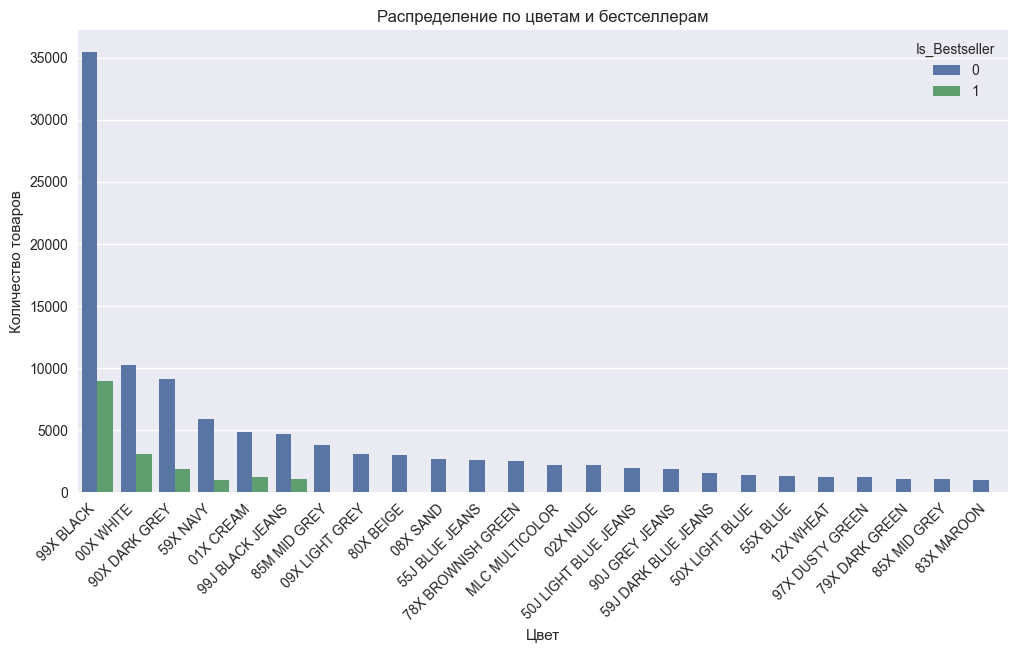

In [908]:
# Посмотрим на распределение бестселлеров по цветам

bardata = data.groupby(['Color_info', 'Is_Bestseller'], as_index=False)['Product_id'].count().sort_values(by='Product_id', ascending=False).head(30)

fig = plt.figure(figsize=(12,6))
sns.barplot(data=bardata, x='Color_info', y='Product_id', hue='Is_Bestseller')
plt.title('Распределение по цветам и бестселлерам')
plt.xlabel('Цвет')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.show();

**Явно преобладает черный цвет, товары белого цвета также продаются неплохо. Также есть еще несколько товаров с неплохими показателями**

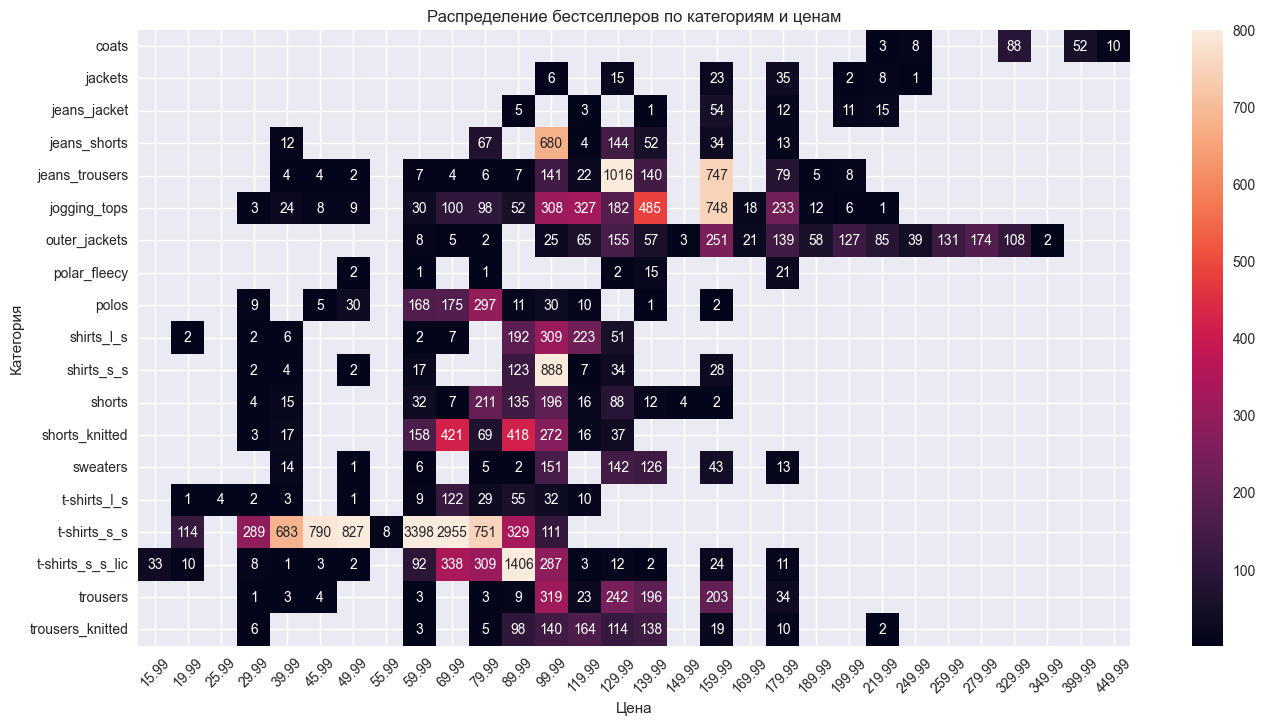

In [909]:
# Посмотрим на распределение бестселлеров по ценам и категориям

pt = pd.pivot_table(
    pivot_data,
    values='Product_id',
    index='Category',
    columns='Actual_Price',
    aggfunc='count'
)

fig = plt.figure(figsize=(16,8))
sns.heatmap(pt, annot=True, fmt='.0f', vmax=800)
plt.xticks(rotation=45, ha='center')
plt.title('Распределение бестселлеров по категориям и ценам')
plt.xlabel('Цена')
plt.ylabel('Категория')
plt.show();

**Определенно видим, что почти во всех категориях есть своя главная цена, на которую приходится больший % бестселлеров, чем на остальные**

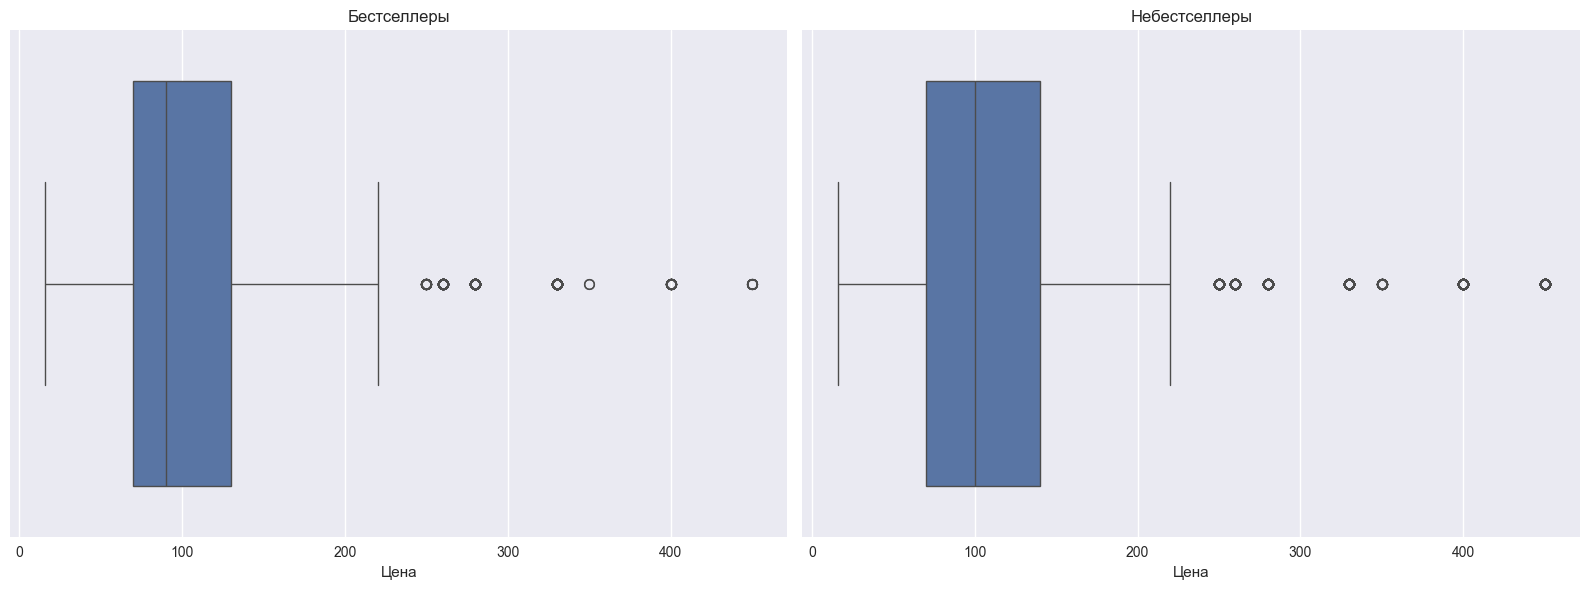

In [911]:
# Изучим влияние цен на бестселлеры, разделив данные на две группы: бестселлеры и небестселлеры

group1 = data[data['Is_Bestseller'] == 1]['Actual_Price']
group0 = data[data['Is_Bestseller'] == 0]['Actual_Price']

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(16,6))
sns.boxplot(group1, orient='h', ax=ax[0], label='group1')
sns.boxplot(group0, orient='h', ax=ax[1], label='group0')
ax[0].set_title('Бестселлеры')
ax[0].set_xlabel('Цена')
ax[1].set_title('Небестселлеры')
ax[1].set_xlabel('Цена')
plt.tight_layout()
plt.show();

**Видим, что у бестселлеров медиана цен немного смещена в меньшую сторону. То есть мы можем наблюдать, что товары с более низкой ценой имеют большую вероятность стать бестселлером**

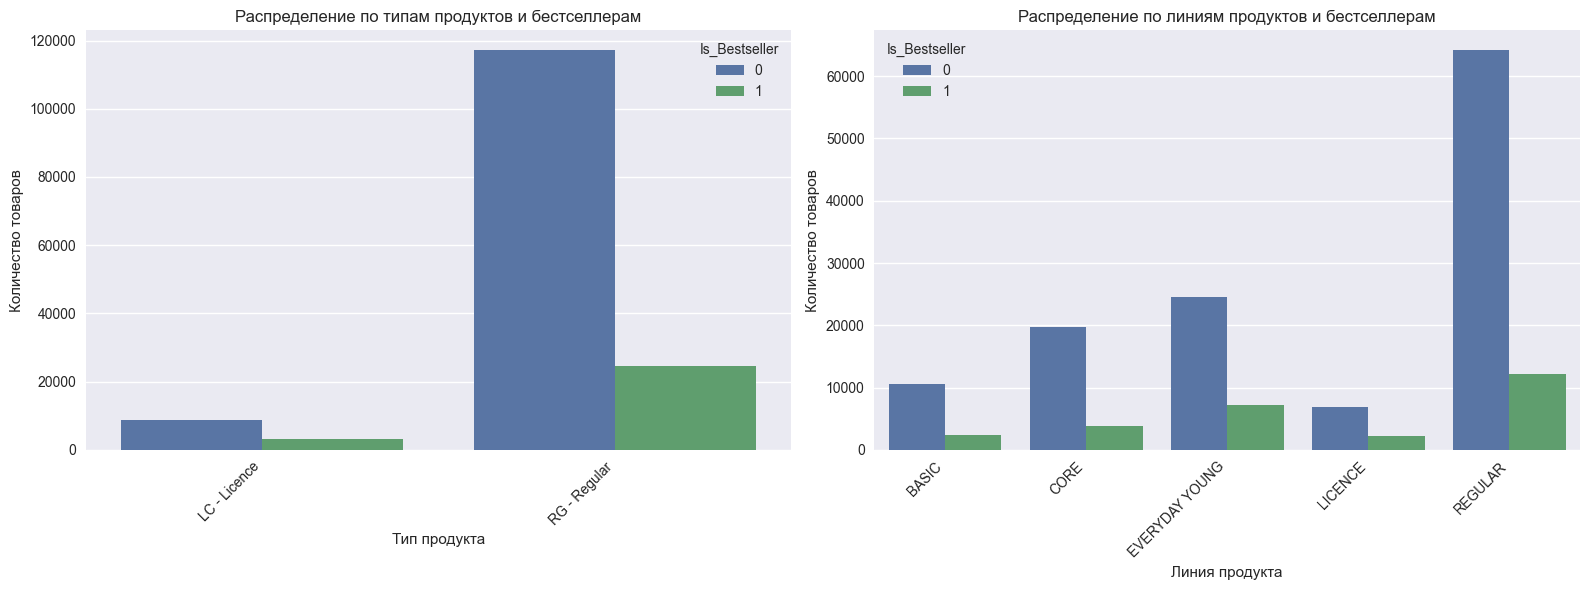

In [912]:
# Изучим распределение бестселлеров по типам продуктов и линиям продуктов

typedata = data.groupby(['Product_Type', 'Is_Bestseller'], as_index=False)['Product_id'].count()
linedata = data.groupby(['Product_Line', 'Is_Bestseller'], as_index=False)['Product_id'].count()

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(16,6))
sns.barplot(data=typedata, x='Product_Type', y='Product_id', hue='Is_Bestseller', ax=ax[0])
sns.barplot(data=linedata, x='Product_Line', y='Product_id', hue='Is_Bestseller', ax=ax[1])
fig.autofmt_xdate(rotation=45)
ax[0].set_title('Распределение по типам продуктов и бестселлерам')
ax[0].set_xlabel('Тип продукта')
ax[0].set_ylabel('Количество товаров')
ax[1].set_title('Распределение по линиям продуктов и бестселлерам')
ax[1].set_xlabel('Линия продукта')
ax[1].set_ylabel('Количество товаров')
plt.tight_layout()
plt.show();


**Большая часть бестселлеров приходится на регулярную коллекцию, однако для лицензионных товаров процент выше.
Что касается линии, то также видно, что на регулярную линию приходится большая часть, однако дополнительно, можем выделить линию для молодых**

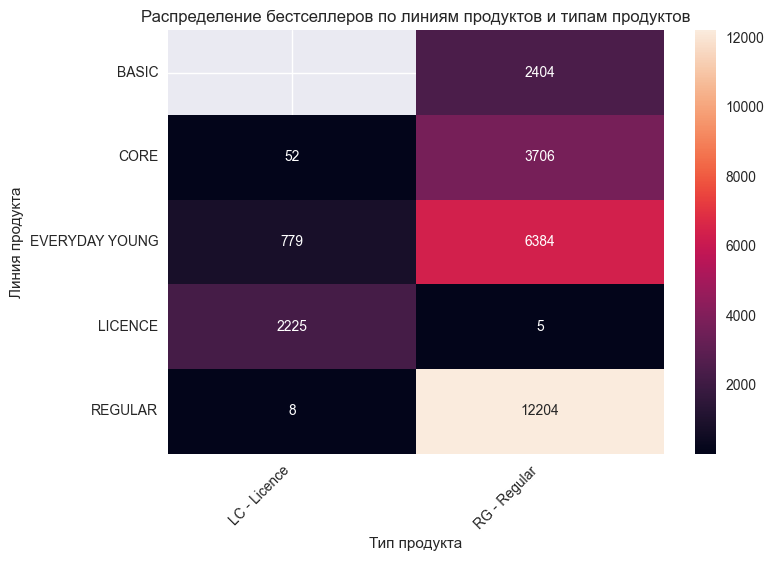

In [913]:
# Посмотрим на распределение бестселлеров по типам продуктов и линиям продуктов в виде тепловой карты

pt = pd.pivot_table(
    pivot_data,
    values='Product_id',
    index='Product_Line',
    columns='Product_Type',
    aggfunc='count'
)

sns.heatmap(pt, annot=True, fmt='.0f')
plt.title('Распределение бестселлеров по линиям продуктов и типам продуктов')
plt.xlabel('Тип продукта')
plt.ylabel('Линия продукта')
plt.xticks(rotation=45, ha='right')
plt.show();

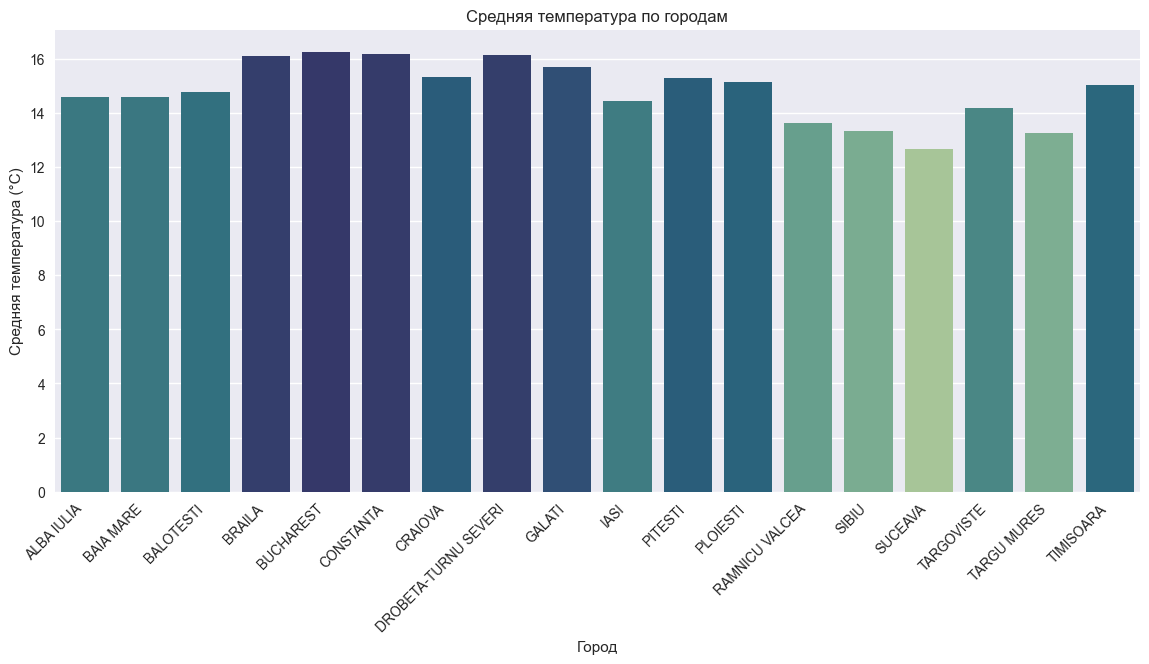

In [914]:
# Посмотрим на распределение средней температуры по городам

bardata = data.groupby(['City'], as_index=False)['tavg_7d'].mean()

fig = plt.figure(figsize=(14,6))
sns.barplot(data=bardata, x='City', y='tavg_7d', hue='tavg_7d', palette='crest', legend=False)
plt.title('Средняя температура по городам')
plt.xlabel('Город')
plt.ylabel('Средняя температура (°C)')
plt.xticks(rotation=45, ha='right')
plt.show();


**В целом средняя температура в городах подобная, однако выделяется группа из нескольких городов, в которых немного холоднее**

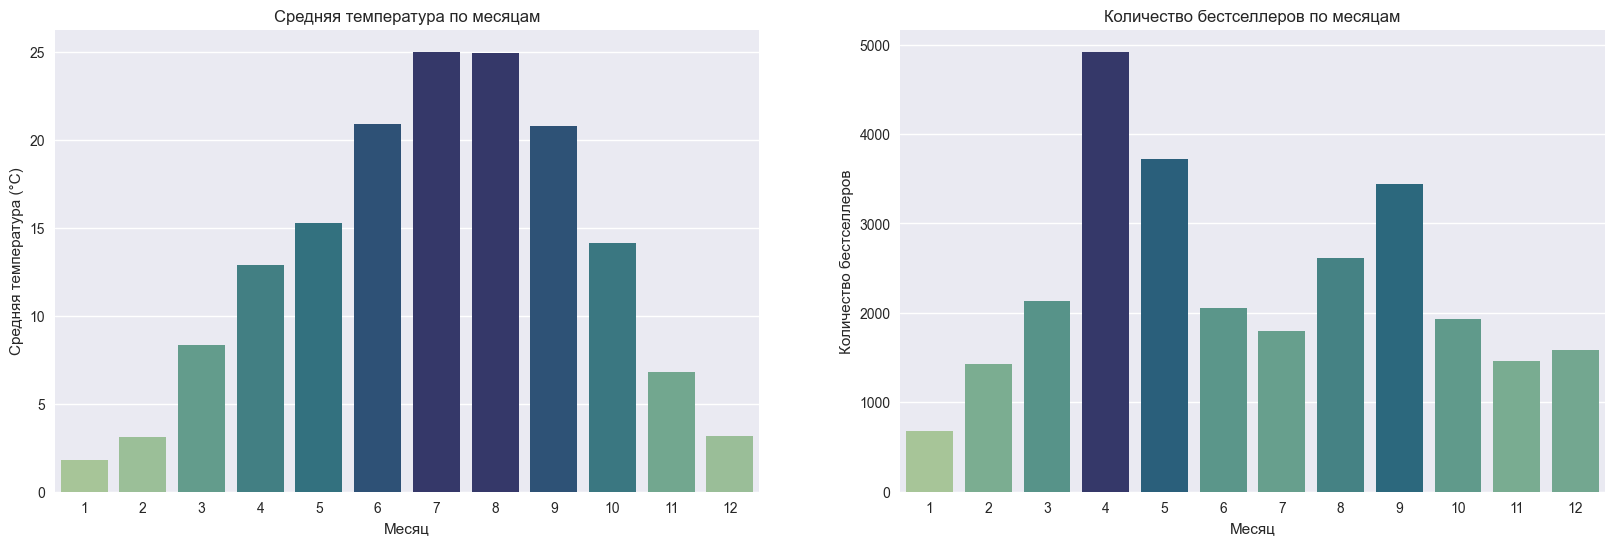

In [915]:
# Посмотрим на распределене погоды по месяцам и распределению количества бестселлеров в зависимости от месяца

bestdata = data.groupby(['Month'], as_index=False)['Is_Bestseller'].sum()
month = data.groupby(['Month'], as_index=False)['tavg_7d'].mean()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,6))
sns.barplot(data=month, x='Month', y='tavg_7d', hue='tavg_7d', palette='crest', legend=False, ax=ax[0])
sns.barplot(data=bestdata, x='Month', y='Is_Bestseller', hue='Is_Bestseller', palette='crest', legend=False, ax=ax[1])
ax[0].set_title('Средняя температура по месяцам')
ax[0].set_xlabel('Месяц')
ax[0].set_ylabel('Средняя температура (°C)')
ax[1].set_title('Количество бестселлеров по месяцам')
ax[1].set_xlabel('Месяц')
ax[1].set_ylabel('Количество бестселлеров')
plt.show();

**На графике погоды мы видим, что температура логично растет к лету, и убывает к зиме. Однако на графике распределение бестселлеров, мы видим, что большая часть приходится на апрель, август и сентябрь. Возможно, влияет фактор, что люди начинают покупать одежду перед сменой сезонов, когда начинает теплеть и когда начинает холодать**

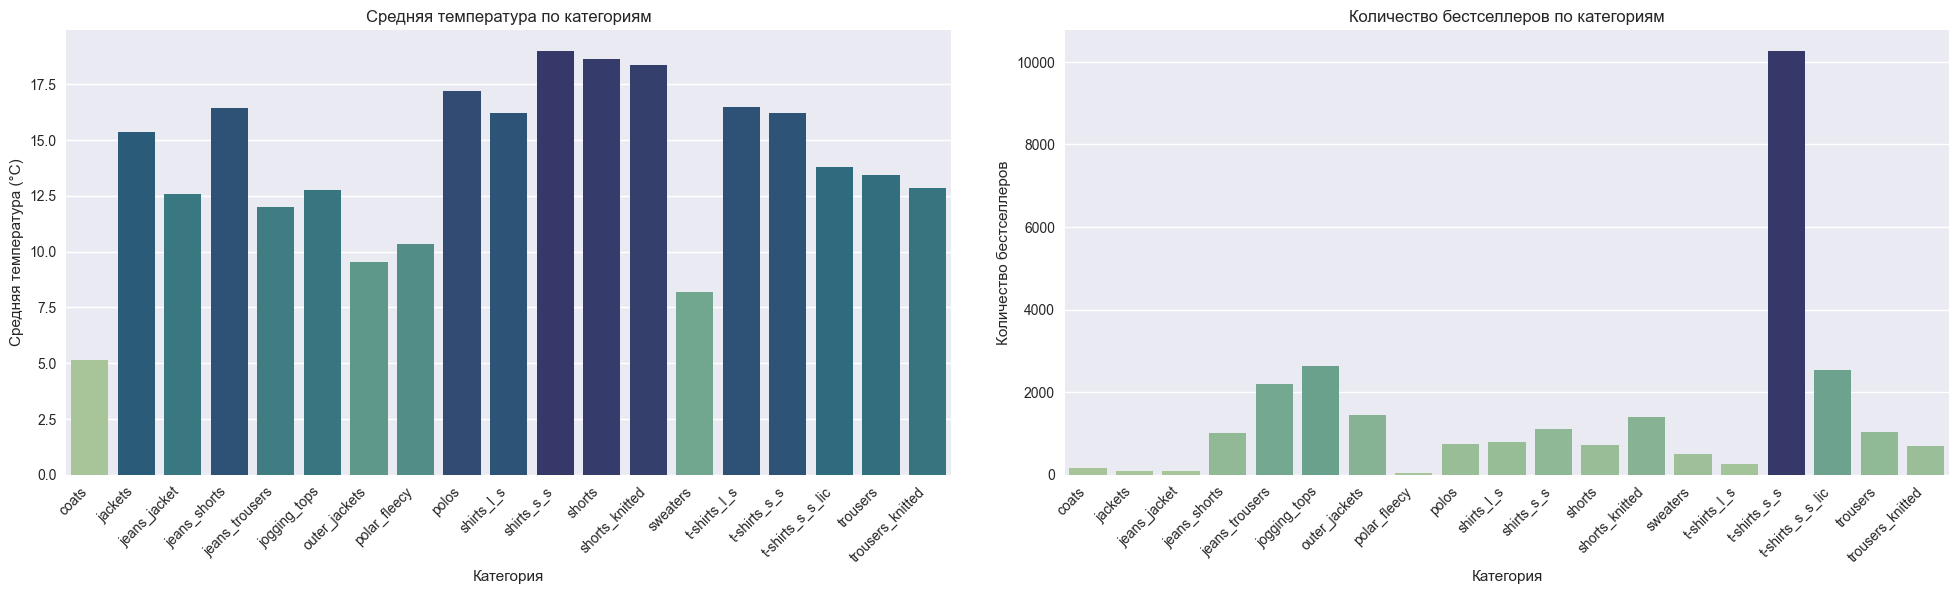

In [916]:
# Аналогично посмотрим на распределение погоды и бестселлеров по категориям

bardata = data[data['Is_Bestseller'] == 1]
weatherbar = bardata.groupby(['Category'], as_index=False)['tavg_7d'].mean()
categorybar = bardata.groupby(['Category'], as_index=False)['Is_Bestseller'].count()

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,6))
sns.barplot(data=weatherbar, x='Category', y='tavg_7d', hue='tavg_7d', palette='crest', legend=False, ax=ax[0])
sns.barplot(data=categorybar, x='Category', y='Is_Bestseller', hue='Is_Bestseller', palette='crest', legend=False, ax=ax[1])
ax[0].set_title('Средняя температура по категориям')
ax[0].set_xlabel('Категория')
ax[0].set_ylabel('Средняя температура (°C)')
ax[1].set_title('Количество бестселлеров по категориям')
ax[1].set_xlabel('Категория')
ax[1].set_ylabel('Количество бестселлеров')
plt.tight_layout()
fig.autofmt_xdate(rotation=45)
plt.show();

**Также все логично, что товары летнего предлодения продаются лучше, когда температура более высокая, аналогично с товарами "из осенне-зимнего предложения"**

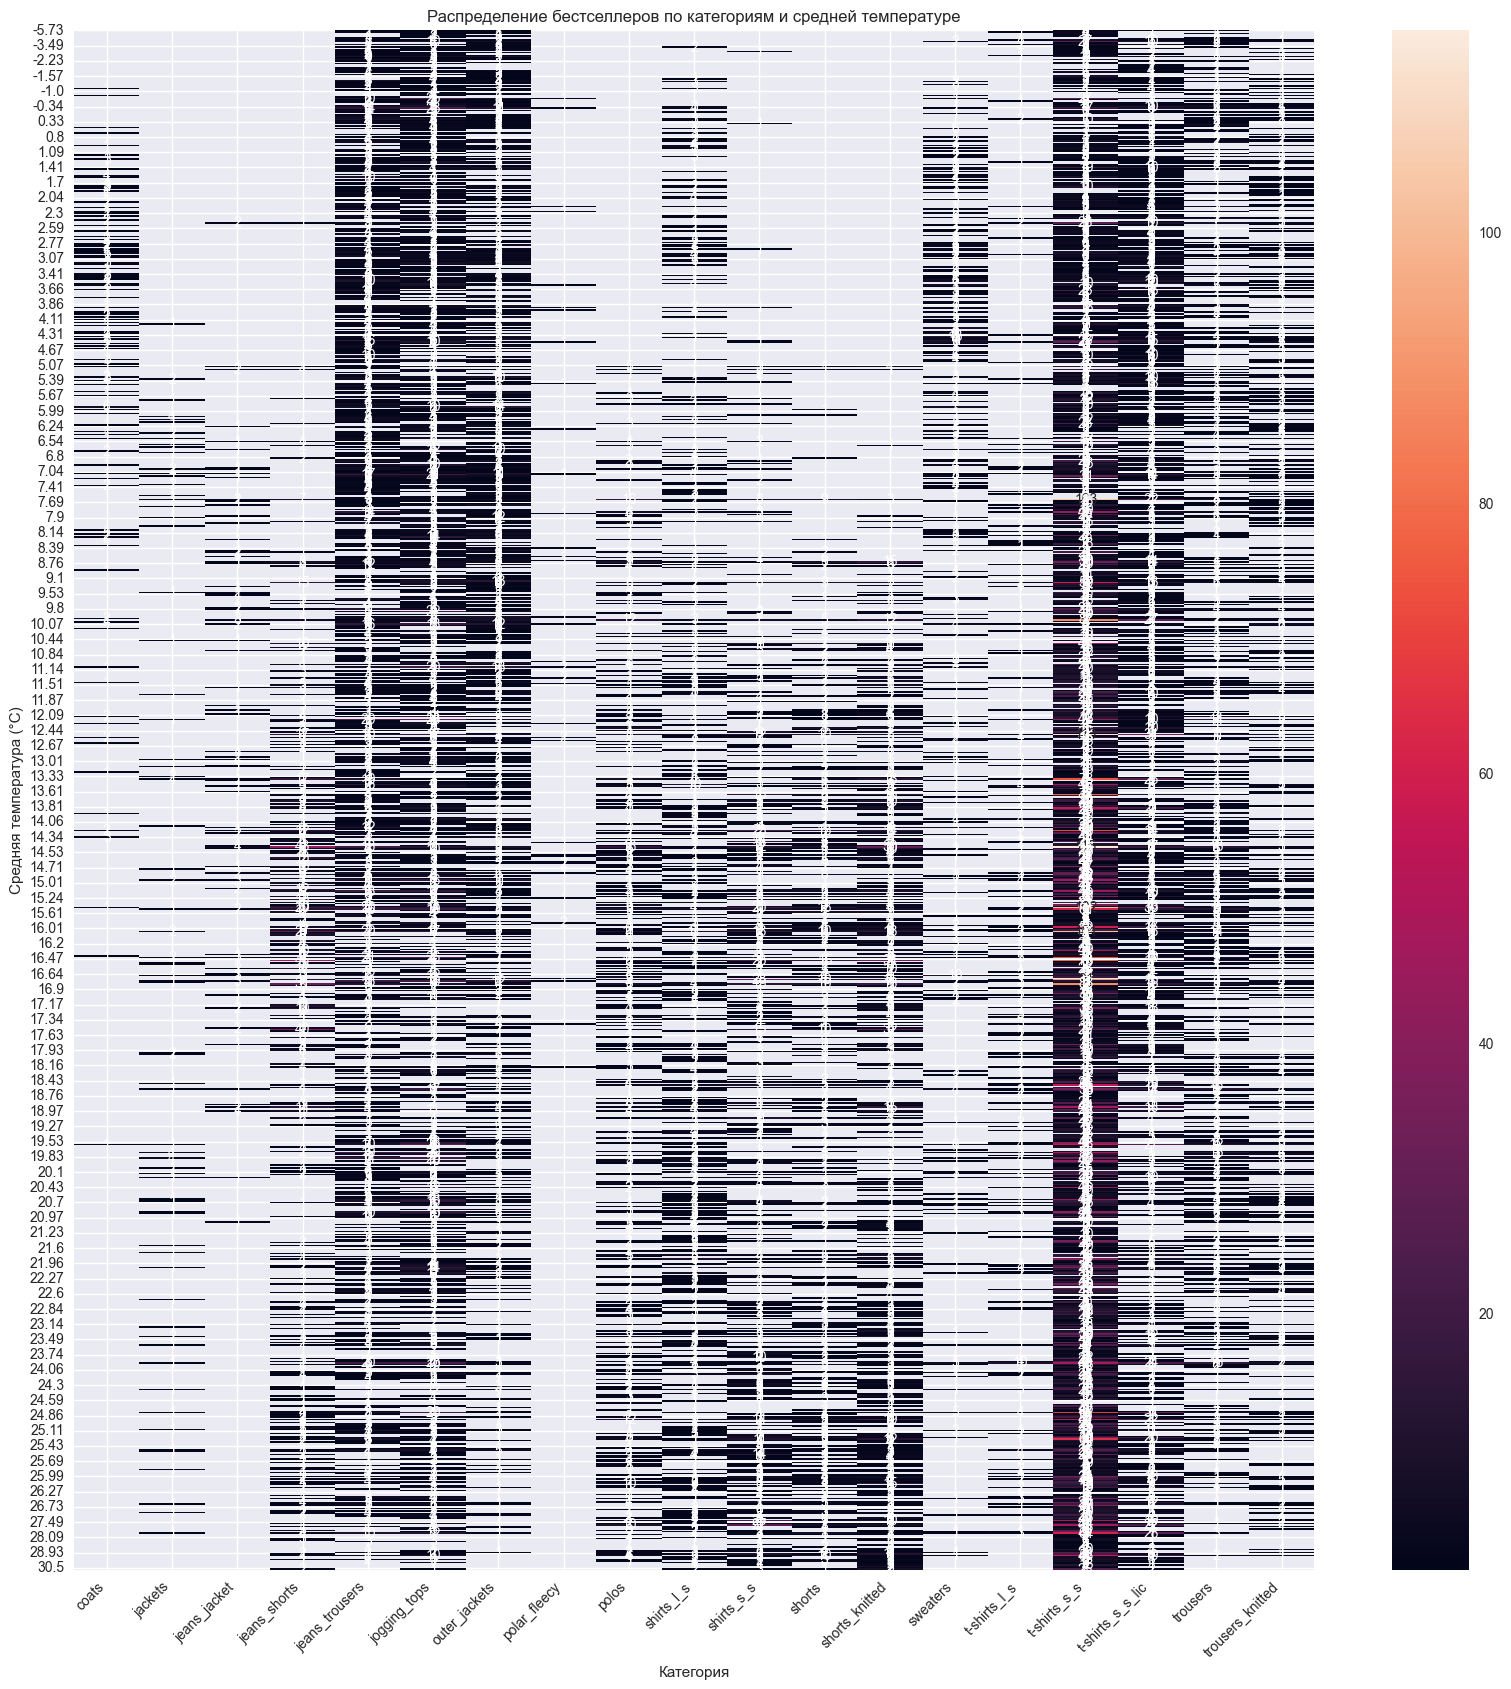

In [918]:
# Посмотрим на распределение погоды и бестселлеров по категориям и средней температуре

pt = pd.pivot_table(
    pivot_data,
    values='Product_id',
    index='tavg_7d',
    columns='Category',
    aggfunc='count'
)

fig = plt.figure(figsize=(20,20))
sns.heatmap(pt, annot=True, fmt='.0f')
plt.title('Распределение бестселлеров по категориям и средней температуре')
plt.xlabel('Категория')
plt.ylabel('Средняя температура (°C)')
plt.xticks(rotation=45, ha='right')
plt.show();

## 3. Статистические анализ данных

### 3.1 Корреляционный анализ числовых признаков

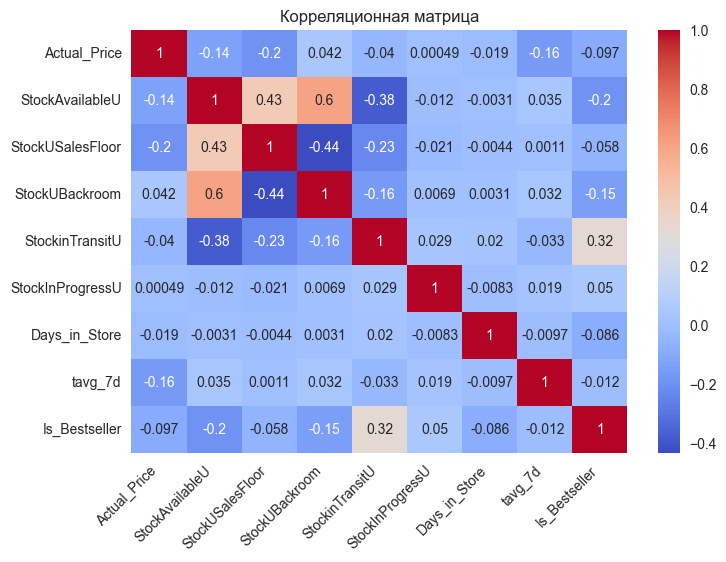

In [919]:
# Посмотрим на корреляцию между числовыми признаками

numeric_cols = ['Actual_Price', 'StockAvailableU', 'StockUSalesFloor', 'StockUBackroom',
                'StockinTransitU', 'StockInProgressU', 'Days_in_Store', 'tavg_7d', 'Is_Bestseller']

sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Корреляционная матрица")
plt.xticks(rotation=45, ha='right')
plt.show();

### 3.2 Проверка категориальных признаков 

In [734]:
# Проверим зависимости между категориальными признаками и целевой переменной Is_Bestseller с помощью критерия хи-квадрат

categorical_features = [
    'Category', 'Current_Season', 'Price_Status', 'StatusSale','IsReplenBlocked', 
    'City', 'Store_Name', 'Product_Line', 'Price_Category', 'Method', 
    'Color_info', 'Product_Type', 'Product_Shape', 'Main_Fabric'
]

for col in categorical_features:
    contingency = pd.crosstab(data[col], data['Is_Bestseller'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"{col}: p-value = {p:.5f}")

Category: p-value = 0.00000
Current_Season: p-value = 0.00000
Price_Status: p-value = 0.00000
StatusSale: p-value = 0.23948
IsReplenBlocked: p-value = 0.00000
City: p-value = 0.00000
Store_Name: p-value = 0.00000
Product_Line: p-value = 0.00000
Price_Category: p-value = 0.00029
Method: p-value = 0.00000
Color_info: p-value = 0.00000
Product_Type: p-value = 0.00000
Product_Shape: p-value = 0.00000
Main_Fabric: p-value = 0.00000


**Как видим, между признаками и целевой переменной существует статистически значимая зависимость почти для всех признаков, кроме `StatusSale`**

### 3.3 Тесты по Средней Температуре и Актуальной Цене

Гипотезы Shapiro-Wilk:

* H0 (нулевая гипотеза): выборка имеет нормальное распределение

* H1 (альтернативная гипотеза): выборка не имеет нормального распределения

Если **p < α = 0.05**, мы отвергаем H0 — нормальность не соблюдается.

In [920]:
# Проверим нормальность распределения целевой переменной Is_Bestseller по температуре tavg_7d с помощью теста Шапиро-Уилка

group1 = data[data['Is_Bestseller'] == 1]['tavg_7d']
group0 = data[data['Is_Bestseller'] == 0]['tavg_7d']

# Проверка нормальности

stat1, p1 = shapiro(group1.sample(5000, random_state=1)) 
stat0, p0 = shapiro(group0.sample(5000, random_state=1))

alpha = 0.05
print("Группа 1 (Bestsellers):")
print(f"  p-value = {p1:.5f} -> {'Нормальность подтверждена' if p1 > alpha else 'Нормальность отвергнута'}")

print("Группа 0 (Non-Bestsellers):")
print(f"  p-value = {p0:.5f} -> {'Нормальность подтверждена' if p0 > alpha else 'Нормальность отвергнута'}")


Группа 1 (Bestsellers):
  p-value = 0.00000 -> Нормальность отвергнута
Группа 0 (Non-Bestsellers):
  p-value = 0.00000 -> Нормальность отвергнута


Гипотезы Mann–Whitney:

H0: Распределения tavg_7d у бестселлеров и не-бестселлеров одинаковы.

H1: Распределения отличаются




In [921]:
# Проверим различия в распределении температур между бестселлерами и небестселлерами с помощью теста Манна-Уитни, так как данные не нормальны

group1 = data[data['Is_Bestseller'] == 1]['tavg_7d']
group0 = data[data['Is_Bestseller'] == 0]['tavg_7d']

# Выполним тест Манна-Уитни для сравнения двух групп

stat, p = mannwhitneyu(group1, group0, alternative='two-sided')

alpha = 0.05
print(f"Mann–Whitney U-test: p-value = {p:.5f}")
print("Вывод:", "Распределения различаются (отвергаем H0)" if p < alpha else "Нет статистически значимых различий (не отвергаем H0)")


Mann–Whitney U-test: p-value = 0.00000
Вывод: Распределения различаются (отвергаем H0)


In [922]:
# Проверим нормальность распределения целевой переменной Is_Bestseller по температуре Actual_Price с помощью теста Шапиро-Уилка

group1 = data[data['Is_Bestseller'] == 1]['Actual_Price']
group0 = data[data['Is_Bestseller'] == 0]['Actual_Price']

# Проверка нормальности
stat1, p1 = shapiro(group1.sample(5000, random_state=1))  # ограничим размер, иначе warning
stat0, p0 = shapiro(group0.sample(5000, random_state=1))

alpha = 0.05
print("Группа 1 (Bestsellers):")
print(f"  p-value = {p1:.5f} -> {'Нормальность подтверждена' if p1 > alpha else 'Нормальность отвергнута'}")

print("Группа 0 (Non-Bestsellers):")
print(f"  p-value = {p0:.5f} -> {'Нормальность подтверждена' if p0 > alpha else 'Нормальность отвергнута'}")

Группа 1 (Bestsellers):
  p-value = 0.00000 -> Нормальность отвергнута
Группа 0 (Non-Bestsellers):
  p-value = 0.00000 -> Нормальность отвергнута


In [923]:
# Проверим различия в распределении цен между бестселлерами и небестселлерами с помощью теста Манна-Уитни, так как данные не нормальны

group1 = data[data['Is_Bestseller'] == 1]['Actual_Price']
group0 = data[data['Is_Bestseller'] == 0]['Actual_Price']

# Выполним тест Манна-Уитни для сравнения двух групп

stat, p = mannwhitneyu(group1, group0, alternative='two-sided')

alpha = 0.05
print(f"Mann–Whitney U-test: p-value = {p:.5f}")
print("Вывод:", "Распределения различаются (отвергаем H0)" if p < alpha else "Нет статистически значимых различий (не отвергаем H0)")

Mann–Whitney U-test: p-value = 0.00000
Вывод: Распределения различаются (отвергаем H0)


### 3.4 Baseline

**Создадим Baseline, чтобы понимать от чего отталкиваться**

In [926]:
# Выбор простых признаков

features = ['tavg_7d', 'StockAvailableU', 'Actual_Price', 'Category', 'City', 'Store_Name']
df_model = data[features + ['Is_Bestseller']].dropna()

# Кодируем признаки

df_encoded = pd.get_dummies(df_model, columns=['Category', 'City', 'Store_Name'], drop_first=True, dtype='int')

# Разделяем данные на обучающую и тестовую выборки

X = df_encoded.drop('Is_Bestseller', axis=1)
y = df_encoded['Is_Bestseller']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

# Обучаем модель логистической регрессии, параметры стандартные
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, model.predict(X_test)))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.84      0.98      0.90     41587
           1       0.61      0.16      0.25      9163

    accuracy                           0.83     50750
   macro avg       0.72      0.57      0.58     50750
weighted avg       0.80      0.83      0.79     50750



**Модель слабо находит класс 1 (бестселлеры, только 16% класса 1 было найдено, и только 61% действительно были классом 1). Метрика f1 слабая, при этом средневзвешенныая метрика f1 достаточно высокая. Логично, так как модель хорошо находит класс 0. Перейдем к работе с признаками, чтобы усилить нашу модель**

## 4. Feature Engineering

### 4.1 Feature Creation & Transformation

In [1178]:
# Функция для предобработки данных о запасах

def stock_preprocessing(df):
    """Преобразует данные о запасах в бинарные признаки, указывающие на доступность товара в разных состояниях.

    Args:
        df (DataFrame): DataFrame с данными о запасах, содержащий следующие столбцы:
            - 'StockAvailableU': количество товара в наличии
            - 'StockUSalesFloor': количество товара в торговом зале
            - 'StockUBackroom': количество товара на складе
            - 'StockinTransitU': количество товара в пути
            - 'StockInProgressU': количество товара в процессе обработки к транзиту

    Returns:
        DataFrame: DataFrame с добавленными бинарными признаками:
    """
    df['Is_StockAvailable'] = df['StockAvailableU'].apply(lambda x: 1 if x >=5 else 0)
    df['Is_Salesfloor'] = df['StockUSalesFloor'].apply(lambda x: 1 if x >=5 else 0)
    df['Is_Backroom'] = df.apply(lambda x: 1 if (x['StockAvailableU'] >= 5 and x['StockUSalesFloor'] < 5) else 0, axis=1)
    df['Is_transit'] = df['StockinTransitU'].apply(lambda x: 1 if x > 0 else 0)
    df['Is_progress'] = df['StockInProgressU'].apply(lambda x: 1 if x > 0 else 0)
    
    return df

In [ ]:
# Определим функцию для расчета отношения бестселлеров к общему количеству товаров в разных группах и сохраним в отдельные файлы

def calculate_all_ratios(df):
    
    """Вычисляет агрегированные коэффициенты бестселлеров и сохраняет их."""
    
    def agg(df, group_cols, name):
        res = df.groupby(group_cols)['Is_Bestseller'].mean().reset_index()
        res.rename(columns={'Is_Bestseller': name}, inplace=True)
        return res

    store_ratio = agg(df, ['Store_Name', 'Category'], 'Store_Bestsellers_ratio')
    city_ratio = agg(df, ['City', 'Category'], 'City_Ratio')
    month_ratio = agg(df, ['Month', 'Category'], 'Month_Ratio')
    category_ratio = agg(df, ['Category'], 'Category_Ratio')
    price_ratio = agg(df, ['Actual_Price', 'Category'], 'Price_Ratio')
    product_type_ratio = agg(df, ['Product_Type'], 'Product_Type_Ratio')

    # сохраняем
    
    store_ratio.to_csv('data/ratios/store_ratio.csv', index=False)
    city_ratio.to_csv('data/ratios/city_ratio.csv', index=False)
    month_ratio.to_csv('data/ratios/month_ratio.csv', index=False)
    category_ratio.to_csv('data/ratios/category_ratio.csv', index=False)
    price_ratio.to_csv('data/ratios/price_ratio.csv', index=False)
    product_type_ratio.to_csv('data/ratios/product_type_ratio.csv', index=False)

calculate_all_ratios(data)

In [1180]:
# Определим функцию для добавления коэффициентов бестселлеров

def apply_all_ratios(df):
    
    """Присоединяет коэффициенты из сохранённых файлов к DataFrame."""
    
    df = df.merge(pd.read_csv('data/ratios/store_ratio.csv'), on=['Store_Name', 'Category'], how='left')
    df = df.merge(pd.read_csv('data/ratios/city_ratio.csv'), on=['City', 'Category'], how='left')
    df = df.merge(pd.read_csv('data/ratios/month_ratio.csv'), on=['Month', 'Category'], how='left')
    df = df.merge(pd.read_csv('data/ratios/category_ratio.csv'), on='Category', how='left')
    df = df.merge(pd.read_csv('data/ratios/price_ratio.csv'), on=['Actual_Price', 'Category'], how='left')
    df = df.merge(pd.read_csv('data/ratios/product_type_ratio.csv'), on='Product_Type', how='left')

    # Заполним пропущенные значения нулями или медианой, если нужно
    ratio_cols = [
        'Store_Bestsellers_ratio', 'City_Ratio', 'Month_Ratio',
        'Category_Ratio', 'Price_Ratio', 'Product_Type_Ratio'
    ]
    for col in ratio_cols:
        df[col] = df[col].fillna(0)

    return df

In [1181]:
# Определим функцию для кодирования категориальных признаков с помощью LabelEncoder

def get_label_encodes(df):
    """Преобразует категориальные признаки в числовые с помощью LabelEncoder.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбцы для кодирования

    Returns:
        DataFrame: DataFrame с закодированными категориальными признаками
    """
    # Список столбцов для кодирования
    
    columns_to_transform = ['Product_Line', 'Product_Type', 'Color_info', 'Category', 'City', 'Store_Name', 'Main_Fabric']
    
    # Кодируем категориальные признаки с помощью LabelEncoder
    
    encoder = LabelEncoder()
    for column in columns_to_transform:
        encoder.fit(df[column])
        df[column] = encoder.transform(df[column])
        
    return df

In [1182]:
# Определим функцию для кодирования категориальных признаков с помощью BinaryEncoder

def get_binary_encodes(df):
    """Преобразует категориальные признаки в числовые с помощью BinaryEncoder.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбцы для кодирования

    Returns:
        DataFrame: DataFrame с закодированными бинарными категориальными признаками
    """
    
    # Список столбцов для кодирования
    
    columns_to_encode = ['Product_Shape']
    
    # Кодируем категориальные признаки с помощью BinaryEncoder, удаляем исходные столбцы
    
    encoder = ce.BinaryEncoder(cols=columns_to_encode)
    encoded = encoder.fit_transform(df[columns_to_encode])
    
    df = pd.concat([df, encoded], axis=1)
    df = df.drop(columns_to_encode, axis=1)
    
    return df  

In [1183]:
# Определим функцию для кодирования категориальных признаков с помощью get_dummies

def get_dummies_encodes(df):
    """Преобразует категориальные признаки в числовые с помощью get_dummies

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбцы для кодирования

    Returns:
        DataFrame: DataFrame с закодированными бинарными категориальными признаками
    """
    
    # Список столбцов для кодирования
    
    columns_to_encode = ['StatusSale', 'IsReplenBlocked', 'Price_Category', 'Method', 'Current_Season', 'Price_Status']
    
    # Кодируем категориальные признаки с помощью BinaryEncoder, удаляем исходные столбцы
    
    dummies_df = pd.get_dummies(df[columns_to_encode], prefix=columns_to_encode, prefix_sep='_', dtype='int')
    
    df = pd.concat([df, dummies_df], axis=1)
    df = df.drop(columns_to_encode, axis=1)
    
    return df

In [1184]:
# Определим функцию для предобработки данных о материалах

def main_fabric_preprocessing(df):
    """Преобразует данные о материалах, добавляя бинарные признаки для хлопка и натуральных тканей.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Main_Fabric'

    Returns:
        DataFrame: DataFrame с добавленными бинарными признаками:
    """
    
    # Список натуральных тканей
    
    natural_fabrics = ['Cotton', 'Cotton_mix', 'Viscose', 'Viscose_mix', 'Linen_mix']
    
    # Добавляем бинарные признаки для хлопка и натуральных тканей
    
    df['Is_Cotton'] = df['Main_Fabric'].eq('Cotton').astype(int)
    df['Is_Natural_Fabric'] = df['Main_Fabric'].isin(natural_fabrics).astype(int)
    
    return df

In [ ]:
# Определим функцию для сохранения топ-N значений столбца по количеству среди бестселлеров

def save_top_values(df, column, top_n, filename):
    """
    Сохраняет топ-N значений столбца `column` по количеству среди бестселлеров.
    """
    
    df_best = df[df['Is_Bestseller'] == 1]
    top_values = df_best[column].value_counts().nlargest(top_n).index.to_list()
    pd.Series(top_values).to_csv(filename, index=False, header=False)


In [1187]:
# Сохраним топовые значения для дальнейшего использования

save_top_values(data, 'Color_info', top_n=10, filename="data/tops/top_colors.csv")
save_top_values(data, 'Category', top_n=6, filename="data/tops/top_categories.csv")
save_top_values(data, 'Actual_Price', top_n=5, filename="data/tops/best_prices.csv")
save_top_values(data, 'Product_Shape', top_n=5, filename="data/tops/top_shapes.csv")

In [1188]:
# Определим функцию для предобработки данных о цветах

def color_preprocessing(df, top_colors_path="data/tops/top_colors.csv"):
    """Преобразует данные о цветах, добавляя бинарные признаки для основных цветов и категорию 'Other'.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Color_info'

    Returns:
        DataFrame: DataFrame с добавленными бинарными признаками
    """
    
    # Создаем список топ-10 цветов на основе бестселлеров
    
    top_colors = pd.read_csv(top_colors_path, header=None).squeeze().tolist()

    # Добавляем бинарные признаки для основных цветов и категорию 'Other'
    
    df['Is_Jeans'] = df['Color_info'].apply(lambda x: 1 if x[2] == 'J' else 0)
    df['Is_Black'] = df['Color_info'].str.startswith('99').astype(int)
    df['Is_White'] = df['Color_info'].str.startswith('00').astype(int)
    
    df['Color_info'] = df['Color_info'].apply(lambda x: x if x in top_colors else 'Other') 
    
    return df

In [1189]:
def category_preprocessing(df, top_categories_path="data/tops/top_categories.csv"):
    """Преобразует данные о категориях, добавляя бинарные признаки для футболок и топовых категорий.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Category'

    Returns:
        DataFrame: DataFrame с добавленными бинарными признаками
    """
    # Создаем список топ-6 категорий на основе бестселлеров
    
    top_categories = pd.read_csv(top_categories_path, header=None).squeeze().tolist()
    
    # Добавляем бинарные признаки для категории t-shirts_s_s и топ-категорий
    
    df['Is_tshirts'] = df['Category'].apply(lambda x: 1 if x == 't-shirts_s_s' else 0) 
    df['Is_top_category'] = df['Category'].apply(lambda x: 1 if (x in top_categories and x != 'shirts_s_s') else 0)
    
    return df

In [1190]:
def price_preprocessing(df, best_prices_path="data/tops/best_prices.csv"):
    """Преобразует данные о цене, добавляя бинарные признаки для лучших цен.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Actual_Price'

    Returns:
        DataFrame: DataFrame с добавленными бинарными признаками
    """
    
    # Создаем список топ-5 цен на основе бестселлеров
    
    best_prices = pd.read_csv(best_prices_path, header=None).squeeze().tolist()
    
    # Добавляем бинарный признак Best_Price
    
    df['Best_Price'] = df['Actual_Price'].apply(lambda x: 1 if x in best_prices else 0)
    
    return df

In [1191]:
def shape_preprocessing(df, top_shapes_path="data/tops/top_shapes.csv"):
    """Преобразует данные о шейпах, добавляя бинарные признаки для топ-5 шейпов.

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'Product_Shape'

    Returns:
        DataFrame: DataFrame с добавленным бинарным признаком
    """
    
    # Создаем список топ-5 шейпов на основе бестселлеров
    
    top_shapes = pd.read_csv(top_shapes_path, header=None).squeeze().tolist()

    # Добавляем бинарный признак Is_top_shape
    
    df['Is_top_shape'] = df['Product_Shape'].apply(lambda x: 1 if x in top_shapes else 0)
    
    return df

In [1192]:
def city_preprocessing(df):
    """Преобразует данные о городах, добавляя бинарный признак для холодных городов

    Args:
        df (DataFrame): DataFrame с данными, содержащий столбец 'City'

    Returns:
        DataFrame: DataFrame с добавленным бинарным признаком
    """
    
    # Создаем список из названий холодных городов
    
    cold_cities =['ramnicu valcea', 'targu mures', 'sibiu']
    
    # Добавляем бинарный признак Is_Cold_City
    
    df['Is_Cold_City'] = df['City'].apply(lambda x: 1 if x.lower() in cold_cities else 0)
    
    return df

In [1193]:
# Применяем функции предобработки данных

data = stock_preprocessing(data)
data = apply_all_ratios(data)
data = color_preprocessing(data, top_colors_path="data/tops/top_colors.csv")
data = main_fabric_preprocessing(data)
data = category_preprocessing(data, top_categories_path="data/tops/top_categories.csv")
data = price_preprocessing(data, best_prices_path="data/tops/best_prices.csv")
data = shape_preprocessing(data, top_shapes_path="data/tops/top_shapes.csv")
data = city_preprocessing(data)

In [ ]:
# Создадам таблицу с агрегированными данными по магазинам

stores = data.groupby('Store_Name', as_index=False).agg({
    'Product_id' : 'count',
    'Is_StockAvailable' : 'sum',
    'Is_Salesfloor' : 'sum',
    'Is_Backroom' : 'sum',
    'Store_Bestsellers_ratio' : 'mean'
    })

In [ ]:
# выделим признаки для обучения модели и создадим выборку X

features = ['Product_id', 'Is_StockAvailable', 'Is_Salesfloor', 'Is_Backroom', 'Store_Bestsellers_ratio']
X = stores[features]

# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Определим функцию для получения коэффициентов силуэта для поиска оптимального количества кластеров

def get_silhouette(cluster_num, model_type, X):
    """Считывает коэффициенты силуэта для заданного количества кластеров и модели.

    Args:
        cluster_num (int): Количество кластеров для оценки
        X (pd.DataFrame): Выборка данных для кластеризации
    """
    silhouette_scores = []
    
    # Обучаем модель и рассчитываем коэффициент силуэта для каждого количества кластеров
    
    for i in range(2, cluster_num):
        model = model_type(
            random_state=RANDOM_STATE,
            n_clusters=i
        )
        clusters = model.fit_predict(X)
        silhouette = round(silhouette_score(X, clusters),4)
        silhouette_scores.append(silhouette)
        print(f'Для {i} кластеров, коэффициент силуэта равен: {silhouette:.3f}')
    
    
    cluster_range = range(2, cluster_num)
    
    # Визуализируем результаты с помощью графика
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.lineplot(
        x=cluster_range,
        y=silhouette_scores,
        markers='o',
        ax=ax
    )
    plt.title(f'Коэффициенты силуэта для алгоритма {model_type}')
    plt.xlabel('Количество кластеров')
    plt.ylabel('Коэффициент силуэта')
    plt.grid(True)
    plt.show();

Для 2 кластеров, коэффициент силуэта равен: 0.406
Для 3 кластеров, коэффициент силуэта равен: 0.284
Для 4 кластеров, коэффициент силуэта равен: 0.401
Для 5 кластеров, коэффициент силуэта равен: 0.374
Для 6 кластеров, коэффициент силуэта равен: 0.360
Для 7 кластеров, коэффициент силуэта равен: 0.399


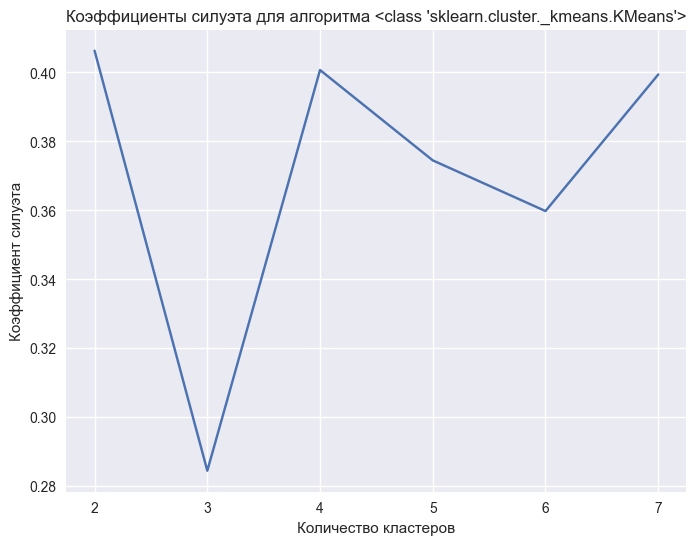

In [947]:
get_silhouette(8, KMeans, X_scaled)

**Выберем 3 кластера, несмотря на то, что лучшие результат показало разделение на 2 кластера. Однако помним, что мы выделли 3 группы магазинов (топы, слабые, середняки)**

In [1075]:
# Определим функцию для добавления признаков кластеров в DataFrame магазинов

def add_cluster_features(X, stores_df, n_clusters=3):
    """Добавляет признаки кластеров в DataFrame магазинов с использованием KMeans.

    Args:
        X (DataFrame): Выборка данных для кластеризации.
        stores_df (DataFrame): DataFrame с данными о магазинах, в который будут добавлены признаки кластеров.
        n_clusters (int, optional): Количество кластеров. Стандартно = 3.

    Returns:
        DataFrame: DataFrame с добавленными признаками кластеров.
    """
    # Определяем модель KMeans с заданным количеством кластеров, обучаем ее и предсказываем кластеры
    
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE)
    clusters = model.fit_predict(X)
    
    stores_df = stores_df.copy()
    stores_df['Cluster'] = clusters
    
    # Сохраняем результат
    
    stores_df.to_csv('data/store_clusters.csv', index=False)
    
    return stores_df    

def add_cluster_to_data(df):
    """Добавляет признак кластера в основной DataFrame с данными о товарах.

    Args:
        df (DataFrame): DataFrame с данными о товарах.

    Returns:
        df: DataFrame с добавленным признаком кластера.
    """
    # Объединяем данные по магазинам и добавляем кластер в основной DataFrame
    
    stores_clustered = pd.read_csv('data/store_clusters.csv')
    
    df = df.merge(
        stores_clustered[['Store_Name', 'Cluster']],
        on='Store_Name',
        how='left'
    )
    
    return df

In [ ]:
add_cluster_features(X_scaled, stores, n_clusters=3)
data = add_cluster_to_data(data)

In [949]:
# Отфильтровываем данные, убирая город Suceava из данных

data = data[~(data['City'] == 'Suceava')]

In [950]:
# Кодируем категориальные признаки с помощью LabelEncoder, BinaryEncoder и get_dummies

data = get_label_encodes(data)
data = get_binary_encodes(data)
data = get_dummies_encodes(data)

In [951]:
# Удалим ненужные столбцы из датасета

data_to_drop = [
    'StatusProductSmartphone', 'Fashion_Level', 'city', 'time', 'Year', 'Store_id', 
    'Product_id', 'StockinTransitU', 'StockInProgressU', 'Date', 'First_Allocation_Date',
    'Days_in_Store', 'Country', 'Product_Composition']
clean_data = data.drop(data_to_drop, axis=1)

In [952]:
# Убедимся, что в данных нет пропусков и все признаки имеют правильные типы

clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153786 entries, 0 to 153785
Data columns (total 57 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Category                    153786 non-null  int32  
 1   Actual_Price                153786 non-null  float64
 2   StockAvailableU             153786 non-null  int64  
 3   StockUSalesFloor            153786 non-null  int64  
 4   StockUBackroom              153786 non-null  int64  
 5   Is_Bestseller               153786 non-null  int64  
 6   City                        153786 non-null  int32  
 7   Store_Name                  153786 non-null  int32  
 8   tavg_7d                     153786 non-null  float64
 9   Product_Line                153786 non-null  int32  
 10  Color_info                  153786 non-null  int32  
 11  Product_Type                153786 non-null  int32  
 12  Main_Fabric                 153786 non-null  int32  
 13  Month         

### 4.2 Feature Selection

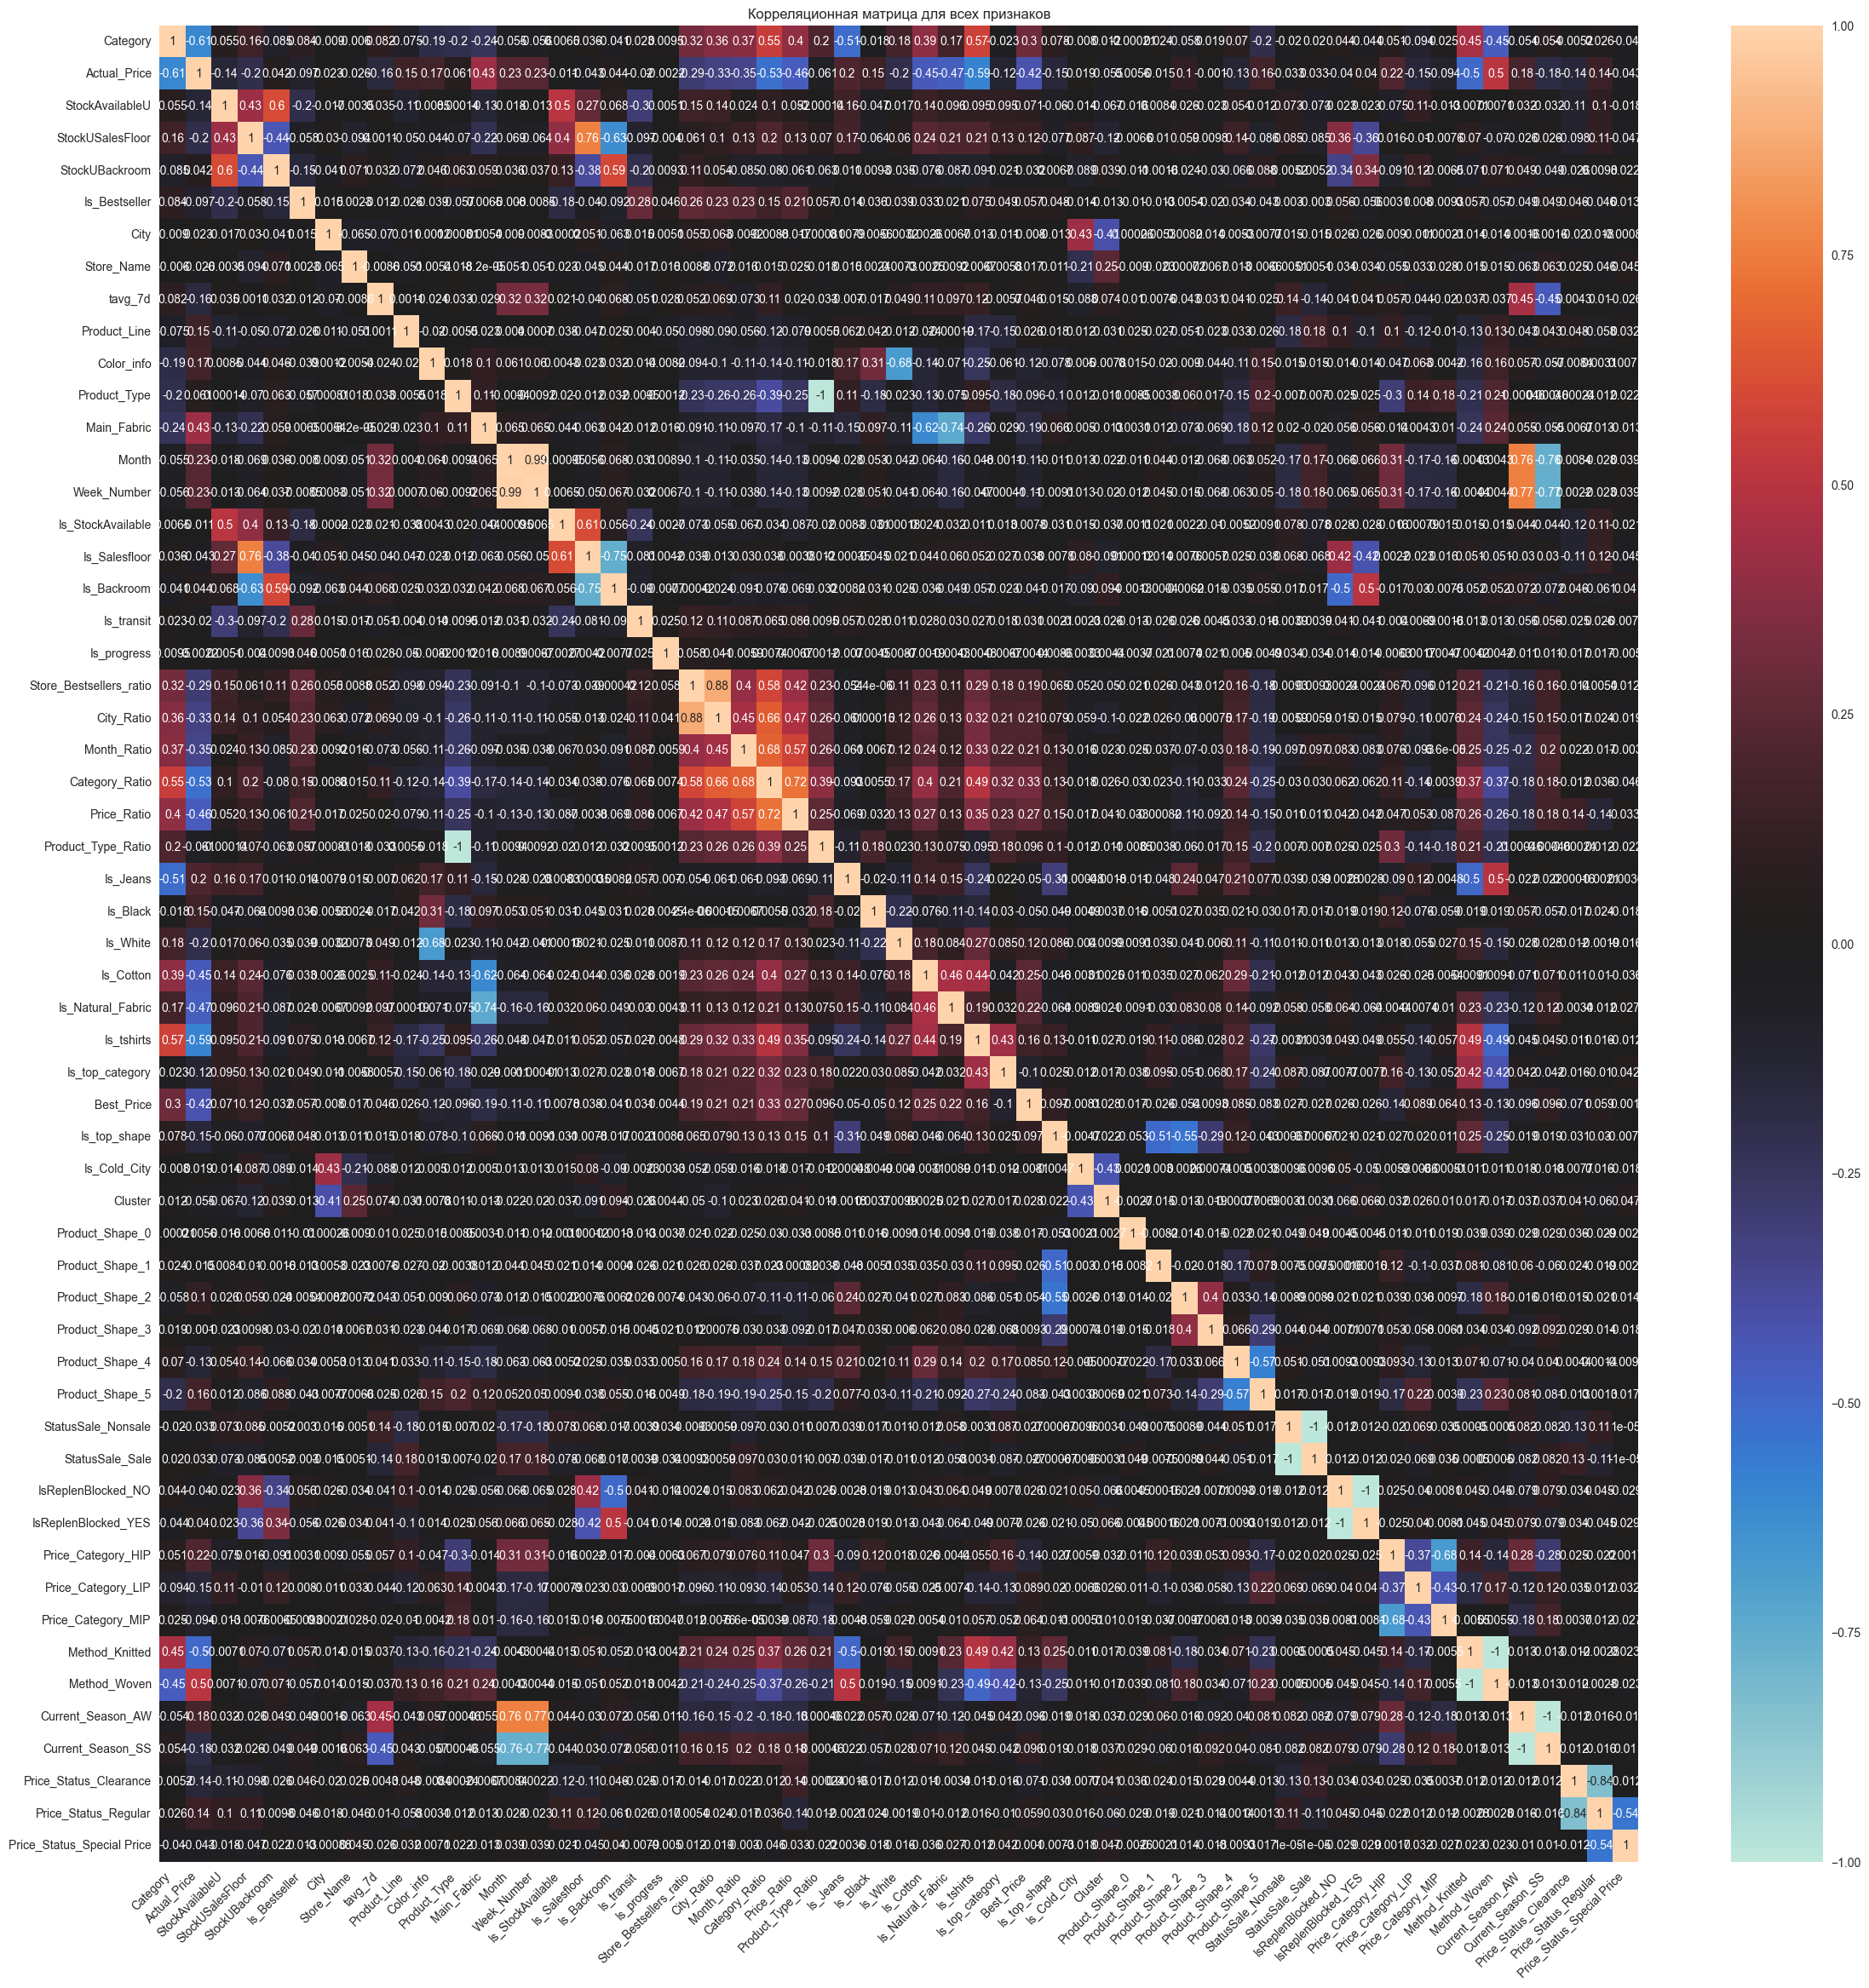

In [955]:
# Построим визуализацию корреляционной матрицы для всех признаков в датасете

plt.figure(figsize=(28,28))
sns.heatmap(clean_data.corr(numeric_only=True), annot=True, center=0);
plt.title("Корреляционная матрица для всех признаков")
plt.xticks(rotation=45, ha='right')
plt.show();

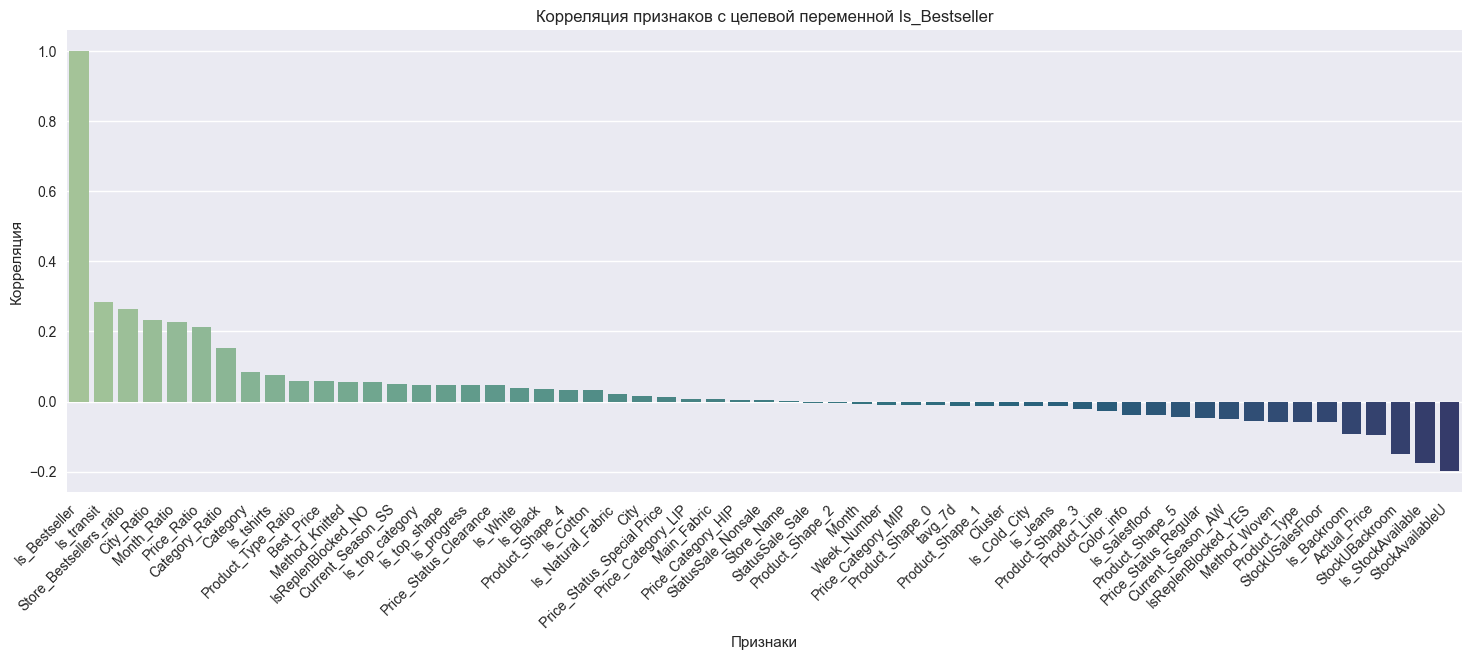

In [ ]:
# Построим график корреляции признаков с целевой переменной Is_Bestseller

correlations = clean_data.corr()['Is_Bestseller']
sorted_correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(18, 6))
sns.barplot(
    x=sorted_correlations.index, 
    y=sorted_correlations.values, 
    palette='crest',
    hue=sorted_correlations.index,
    legend=False
)
plt.title('Корреляция признаков с целевой переменной Is_Bestseller')
plt.xlabel('Признаки')
plt.ylabel('Корреляция')
plt.xticks(rotation=45, ha='right')
plt.show();

In [1194]:
# Удалим из датасета признаки с высокой мультиколлинеарностью, которые имеют корреляцию выше 0.8
def remove_multicollinear_features(df, threshold=0.8):
    """Удаляет признаки с высокой мультиколлинеарностью из DataFrame.

    Args:
        df (DataFrame): DataFrame с данными.
        threshold (float): Порог корреляции для удаления признаков. Стандартно = 0.8.

    Returns:
        DataFrame: DataFrame без признаков с высокой мультиколлинеарностью.
    """
    
    corr_matrix = df.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    
    return df.drop(to_drop, axis=1)



In [ ]:
# Очищаем данные от мультиколлинеарных признаков

clean_data = remove_multicollinear_features(clean_data)

In [958]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153786 entries, 0 to 153785
Data columns (total 49 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Category                    153786 non-null  int32  
 1   Actual_Price                153786 non-null  float64
 2   StockAvailableU             153786 non-null  int64  
 3   StockUSalesFloor            153786 non-null  int64  
 4   StockUBackroom              153786 non-null  int64  
 5   Is_Bestseller               153786 non-null  int64  
 6   City                        153786 non-null  int32  
 7   Store_Name                  153786 non-null  int32  
 8   tavg_7d                     153786 non-null  float64
 9   Product_Line                153786 non-null  int32  
 10  Color_info                  153786 non-null  int32  
 11  Product_Type                153786 non-null  int32  
 12  Main_Fabric                 153786 non-null  int32  
 13  Month         

In [ ]:
# Разделим данные на признаки и целевую переменную

X = clean_data.drop('Is_Bestseller', axis=1)
y = clean_data['Is_Bestseller']

In [960]:
# Разделим данные на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

In [961]:
# Выберем 25 лучших признаков с помощью SelectKBest и f_classif

selector = SelectKBest(
    k=25,
    score_func=f_classif
)

selector.fit(X_train, y_train)
best_features = selector.get_feature_names_out().tolist()
print(f'Признаки выбранные для построения модели: \n {selector.get_feature_names_out()}')

# Преобразуем обучающую и тестовую выборки, оставляя только выбранные признаки

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

Признаки выбранные для построения модели: 
 ['Category' 'Actual_Price' 'StockAvailableU' 'StockUSalesFloor'
 'StockUBackroom' 'Product_Type' 'Is_StockAvailable' 'Is_Salesfloor'
 'Is_Backroom' 'Is_transit' 'Is_progress' 'Store_Bestsellers_ratio'
 'Month_Ratio' 'Category_Ratio' 'Price_Ratio' 'Is_White' 'Is_tshirts'
 'Is_top_category' 'Best_Price' 'Is_top_shape' 'Product_Shape_5'
 'IsReplenBlocked_NO' 'Method_Knitted' 'Current_Season_AW'
 'Price_Status_Clearance']


In [962]:
# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [963]:
# Масштабируем данные с помощью StandardScaler для выбранных признаков

scaler = StandardScaler()
scaler.fit(X_train_selected)
X_train_scaled_selected = scaler.transform(X_train_selected)
X_test_scaled_selected = scaler.transform(X_test_selected)

## 5. Modeling

### 5.1 Logistic Regression

In [964]:
# Обучим модель логистической регрессии на всех признаках

lr = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, lr_pred))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.86      0.96      0.91     41587
           1       0.65      0.30      0.41      9163

    accuracy                           0.84     50750
   macro avg       0.75      0.63      0.66     50750
weighted avg       0.82      0.84      0.82     50750



In [966]:
# Обучим модель логистической регрессии на выбранных признаках

lr = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled_selected, y_train)
lr_pred = lr.predict(X_test_scaled_selected)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, lr_pred))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.86      0.96      0.91     41587
           1       0.64      0.28      0.39      9163

    accuracy                           0.84     50750
   macro avg       0.75      0.62      0.65     50750
weighted avg       0.82      0.84      0.82     50750



**Видим небольшое преимущество в модели, на всех признаках. Попробуем построить модель на всех признаках. 
Что касается сравнения с Baseline, видим, что после работы с признаками, нам удалось улучшить перфоманс модели, достигли результата 0.39 по метрике f1, улучшили Recall для класса 1, но все еще есть что улучшать**

In [967]:
# Подберем гиперпараметры для модели логистической регрессии с помощью GridSearchCV

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8],
    }
]

# Используем StratifiedKFold для кросс-валидации, так как классы несбалансированы

skf = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=skf,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.86      0.96      0.91     41587
           1       0.65      0.30      0.41      9163

    accuracy                           0.84     50750
   macro avg       0.75      0.63      0.66     50750
weighted avg       0.82      0.84      0.82     50750

Лучшие гиперпараметры: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


**Незначительно улучшили перфоманс модели, однако этого мало. Класс 1 попрежнему предсказывается слабо**

### 5.2 Decision Tree

In [968]:
# Обучим модель Decision Tree Classifier на всех признаках, оставим параметры по дефолту

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)

# Делаем предсказания на обучающей и тестовой выборках

dt_pred_train = dt.predict(X_train_scaled)
dt_pred_test = dt.predict(X_test_scaled)

print('Результаты для тренировочной выборки', '\n', classification_report(y_train, dt_pred_train))
print('Результаты для тестовой выборки', '\n',classification_report(y_test, dt_pred_test))

Результаты для тренировочной выборки 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     84432
           1       1.00      0.99      1.00     18604

    accuracy                           1.00    103036
   macro avg       1.00      1.00      1.00    103036
weighted avg       1.00      1.00      1.00    103036

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.89      0.89     41587
           1       0.50      0.52      0.51      9163

    accuracy                           0.82     50750
   macro avg       0.70      0.70      0.70     50750
weighted avg       0.82      0.82      0.82     50750



**Модель явно получилась переобученной, попробуем найти оптимальные гиперпараметры, чтобы сбалансировать модель**

In [969]:
# Подберем гиперпараметры для модели дерева решений с помощью GridSearchCV

param_grid = {
    'min_samples_split': range(3,11),
    'max_depth': range(3,11),
    'min_samples_leaf' : range(3,6)
}

skf = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        criterion='entropy'
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.87      0.96      0.92     41587
           1       0.67      0.38      0.48      9163

    accuracy                           0.85     50750
   macro avg       0.77      0.67      0.70     50750
weighted avg       0.84      0.85      0.84     50750

Лучшие гиперпараметры:: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 3}


**Наблюдаем прирост перфоманса по сравнению с моделью логистической регрессии, избавились от переобучения, повысили метрики F1 и Recall, но по прежнему имеем слабый результат по классу 1.**

### 5.3 Ensembles models

In [970]:
# Попробуем обучить модель случайного леса с параметрами подобными к дереву решений

rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    min_samples_split=3,
    min_samples_leaf=5,
    max_depth=10,
    random_state=RANDOM_STATE
)

rf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = rf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.86      0.98      0.92     41587
           1       0.76      0.30      0.43      9163

    accuracy                           0.86     50750
   macro avg       0.81      0.64      0.67     50750
weighted avg       0.85      0.86      0.83     50750



**Возможно промахнулись с параметрами, так как явно видим ухудщения модели. Попробуем найти лучшие параметры**

In [773]:
# Подберем гиперпараметры для модели случайного леса с помощью RandomizedSearchCV

param_grid = {
    'min_samples_split': [5,7,10],
    'max_depth': range(2,11,2),
    'min_samples_leaf' : [3,4,5],
    'n_estimators': [100,300,500]
}

skf = StratifiedKFold(n_splits=3)

search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
    ),
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    n_jobs=-1,
    verbose=True
)

search.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(search.best_params_))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Report for the test set: 
               precision    recall  f1-score   support

           0       0.87      0.98      0.92     41587
           1       0.76      0.32      0.45      9163

    accuracy                           0.86     50750
   macro avg       0.81      0.65      0.68     50750
weighted avg       0.85      0.86      0.83     50750

Best hyperparameter values: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_depth': 10}


**После нахождения параметров модель улучшила перфоманс, однако по нужным нам метрикам мы получили более слабые результаты. Из плюсов отметим, что улучшилась метрика Precision**

In [774]:
# Попробуем обучить модель градиентного бустинга с параметрами подобными к случайному лесу

gb_clf = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=500,
    min_samples_leaf=3,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=True
)

gb_clf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = gb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

      Iter       Train Loss   Remaining Time 
         1           0.9109            7.39m
         2           0.8828            6.94m
         3           0.8586            6.93m
         4           0.8369            6.80m
         5           0.8179            6.68m
         6           0.8004            6.57m
         7           0.7848            6.52m
         8           0.7704            6.44m
         9           0.7568            6.40m
        10           0.7444            6.40m
        20           0.6568            6.71m
        30           0.6048            6.65m
        40           0.5691            6.56m
        50           0.5423            6.35m
        60           0.5192            6.18m
        70           0.4976            6.15m
        80           0.4792            5.96m
        90           0.4644            5.87m
       100           0.4501            5.87m
       200           0.3492            4.16m
       300           0.2788            2.71m
       40

**Градиентный бустинг явно показал прирост в перфомансе по всем метрикам. Хорошо усилились в F1 и Recall, Precision также остался на высоком уровне, по сравнению с другими моделями. Попробуем применить другие модели с градиентным бустингом, и сравним результаты**

In [971]:
# Обучим модель XGBoost с параметрами по дефолту

xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
xgb_clf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = xgb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.96      0.93     41587
           1       0.73      0.48      0.58      9163

    accuracy                           0.87     50750
   macro avg       0.81      0.72      0.75     50750
weighted avg       0.86      0.87      0.86     50750



In [972]:
# Обучим модель CatBoost с параметрами по дефолту

cb_clf = CatBoostClassifier(random_state=42, verbose=False)
cb_clf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = cb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.96      0.93     41587
           1       0.75      0.48      0.58      9163

    accuracy                           0.88     50750
   macro avg       0.82      0.72      0.75     50750
weighted avg       0.87      0.88      0.86     50750



**Модель с использованием алгоритма Catboost показала незначительно лучший и более сбалансированный перфоманс. Присмотримся к этому алгоритму поближе**

### 5.4 Stacking

In [973]:
# Применим стекинг для объединения нескольких моделей

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', C=0.1, penalty='l1', max_iter=10000)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=3, min_samples_leaf=5)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)),
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     41587
           1       0.73      0.49      0.59      9163

    accuracy                           0.88     50750
   macro avg       0.81      0.73      0.76     50750
weighted avg       0.87      0.88      0.87     50750



In [974]:
# Применим стекинг для объединения нескольких моделей, но будем использовать более сложную модель финального классификатора

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', C=0.1, penalty='l1', max_iter=10000)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=3, min_samples_leaf=5)),
    ('gbc', XGBClassifier(random_state=RANDOM_STATE))
]

# Use a logistic regression model with default parameters as the meta-model

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=CatBoostClassifier(random_state=RANDOM_STATE, verbose=False),
    passthrough=True
)

st_clf.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.96      0.93     41587
           1       0.74      0.48      0.58      9163

    accuracy                           0.88     50750
   macro avg       0.81      0.72      0.75     50750
weighted avg       0.87      0.88      0.86     50750



**После применения стэкинга, нам удалось улучшить наши результаты, видим, что хорошо вырасли метрики, однако мы по прежнему в половине случаев не можем найти класс 1**

### 5.5 Oversampling

**Применим инструмент оверсемплирования, чтобы искусственно синтезировать данные класса 1 для тренировочной выборке, и посмотрим, даст ли нам это какой-либо эффект**

In [975]:
# Делим данные на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=RANDOM_STATE)

# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Делаем балансировку классов с помощью SMOTE, так как классы несбалансированы

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [976]:
print(f'Размеры выборки после балансировки: {X_resampled.shape}, {y_resampled.shape}')
print('Распределение классов после балансировки', '\n', y_resampled.value_counts())

Размеры выборки после балансировки: (168864, 48), (168864,)
Распределение классов после балансировки 
 Is_Bestseller
0    84432
1    84432
Name: count, dtype: int64


#### 5.5.1 Logistic Regression

In [977]:
# Подберем гиперпараметры для модели логистической регрессии с помощью GridSearchCV

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8],
    }
]


grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.76      0.84     41587
           1       0.40      0.72      0.52      9163

    accuracy                           0.76     50750
   macro avg       0.66      0.74      0.68     50750
weighted avg       0.83      0.76      0.78     50750

Лучшие гиперпараметры: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


#### 5.5.2 Decision Tree Classifier

In [978]:
# Подберем гиперпараметры для модели дерева решений с помощью GridSearchCV

param_grid = {
    'min_samples_split': range(3,11),
    'max_depth': range(3,11),
    'min_samples_leaf' : range(3,6)
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        criterion='entropy'
    ),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.89      0.89     41587
           1       0.50      0.52      0.51      9163

    accuracy                           0.82     50750
   macro avg       0.70      0.70      0.70     50750
weighted avg       0.82      0.82      0.82     50750

Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 3}


#### 5.5.3 Random Forest Classifier

In [979]:
# Обучим модель случайного леса на сбалансированной выборке

rf = RandomForestClassifier(
    random_state=RANDOM_STATE, 
    n_estimators=500, 
    max_depth=10, 
    min_samples_split=3, 
    min_samples_leaf=3,
    criterion='entropy',
    n_jobs=-1
)

rf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = rf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.85      0.88     41587
           1       0.50      0.66      0.57      9163

    accuracy                           0.82     50750
   macro avg       0.71      0.76      0.73     50750
weighted avg       0.84      0.82      0.83     50750



#### 5.5.4 Gradient Boosting

In [980]:
# Обучим модель XGBoost сбалансированной выборке, параметры по умолчанию

xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
xgb_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = xgb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92     41587
           1       0.69      0.51      0.58      9163

    accuracy                           0.87     50750
   macro avg       0.79      0.73      0.75     50750
weighted avg       0.86      0.87      0.86     50750



In [981]:
# Обучим модель CatBoost сбалансированной выборке, параметры по умолчанию

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
cb_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = cb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     41587
           1       0.73      0.51      0.60      9163

    accuracy                           0.88     50750
   macro avg       0.81      0.73      0.76     50750
weighted avg       0.87      0.88      0.87     50750



#### 5.5.5 Stacking

In [983]:
# Применим стекинг для объединения нескольких моделей (Используем логистическую регрессию (высокий Recall), дерево решений (Сбалансированные метрики) и CatBoost(Высокий f1 и Precision))

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='lbfgs', C=10, penalty='l2', max_iter=10000)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=3, min_samples_leaf=3)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False))
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     41587
           1       0.62      0.62      0.62      9163

    accuracy                           0.86     50750
   macro avg       0.77      0.77      0.77     50750
weighted avg       0.86      0.86      0.86     50750



**На данный момент получили лучшую модель, которая имеет отлично сбалансированный метрики и показала наивысший прирост эффективности**

In [984]:
# Попробуем перебрать веса классов для модели CatBoost, чтобы улучшить метрики

param_grid = {
    'class_weights': [[1, 3], [1, 5], [1, 10]] 
}


grid_search = GridSearchCV(
    estimator=CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=False
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.94      0.86      0.90     41587
           1       0.54      0.73      0.62      9163

    accuracy                           0.84     50750
   macro avg       0.74      0.80      0.76     50750
weighted avg       0.86      0.84      0.85     50750

Лучшие гиперпараметры: {'class_weights': [1, 3]}


In [985]:
# Обучим еще один ансамль из сложных моделей, посмотрим, есть ли какой-либо прирост. Будем использовать изменения веса классов для модели CatBoost

cb_clf = CatBoostClassifier(class_weights=[1,5], random_state=RANDOM_STATE, verbose=False)
xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
lgb_clf = LGBMClassifier(random_state=RANDOM_STATE)

ensemble = VotingClassifier(estimators=[
    ('catboost', cb_clf),
    ('xgboost', xgb_clf),
    ('lightgbm', lgb_clf)
], voting='soft')

ensemble.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = ensemble.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

[LightGBM] [Info] Number of positive: 84432, number of negative: 84432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9347
[LightGBM] [Info] Number of data points in the train set: 168864, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91     41587
           1       0.61      0.61      0.61      9163

    accuracy                           0.86     50750
   macro avg       0.76      0.76      0.76     50750
weighted avg       0.86      0.86      0.86     50750



**Также получили хорошо сбалансированную модель, немного уступающую классическому стэкингу, однако болюю легкую**

#### 5.5.6 Feature Importance

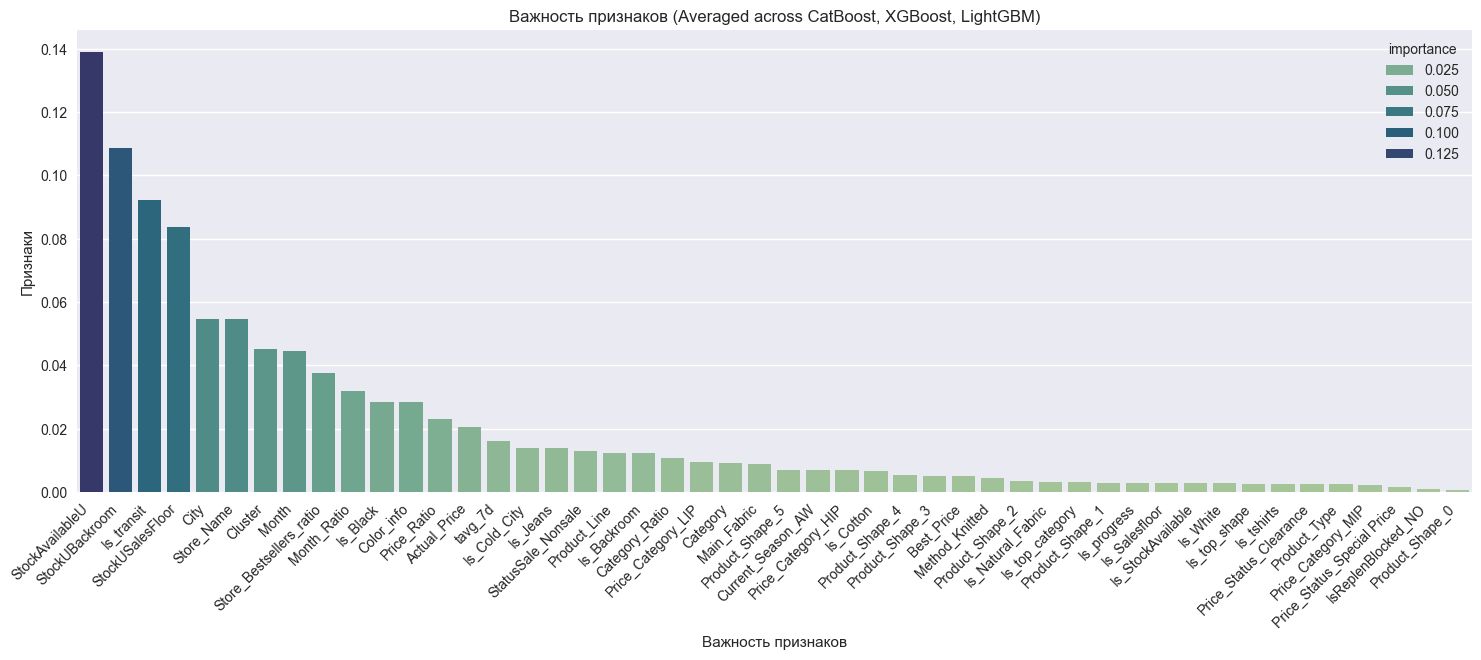

In [986]:
# Получим коэффициенты важности признаков из каждой модели и посмотрим суммарно, какие признаки наиболее важны для предсказания


cb_importance = ensemble.named_estimators_['catboost'].get_feature_importance() # CatBoost
xgb_importance = ensemble.named_estimators_['xgboost'].feature_importances_ # XGBoost
lgb_importance = ensemble.named_estimators_['lightgbm'].feature_importances_ # LightGBM

# Усредняем важность признаков (нормализуем, чтобы они были сравнимы)

cb_importance = cb_importance / cb_importance.sum()
xgb_importance = xgb_importance / xgb_importance.sum()
lgb_importance = lgb_importance / lgb_importance.sum()

# Усредненная важность

avg_importance = (cb_importance + xgb_importance + lgb_importance) / 3

# Создаем DataFrame для визуализации

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': avg_importance
}).sort_values('importance', ascending=False)

# Визуализация
plt.figure(figsize=(18, 6))
sns.barplot(data=feature_importance, x='feature', y='importance', palette='crest', hue='importance')
plt.title('Важность признаков (Averaged across CatBoost, XGBoost, LightGBM)')
plt.xlabel('Важность признаков')
plt.ylabel('Признаки')
plt.xticks(rotation=45, ha='right')
plt.show();

### 5.6 Top Features

In [1018]:
# Выделим топ признаков, которые имеют важность больше 0.01

top_features = feature_importance[feature_importance['importance'] > 0.01]['feature']

# Разделим данные на обучающую и тестовую выборки, используя только топ-признаки

X = clean_data[top_features]
y = clean_data['Is_Bestseller']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=RANDOM_STATE)

# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Произведем балансировку классов с помощью SMOTE, так как классы несбалансированы

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [988]:
print(f'Размеры выборки после балансировки: {X_resampled.shape}, {y_resampled.shape}')
print('Распределение классов после балансировки', '\n', y_resampled.value_counts())

Размеры выборки после балансировки: (168864, 21), (168864,)
Распределение классов после балансировки 
 Is_Bestseller
0    84432
1    84432
Name: count, dtype: int64


#### 5.6.1 Logistic Regression

In [989]:
# Подберем гиперпараметры для модели логистической регрессии с помощью GridSearchCV

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8],
    }
]


grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.76      0.83     41587
           1       0.40      0.72      0.51      9163

    accuracy                           0.75     50750
   macro avg       0.66      0.74      0.67     50750
weighted avg       0.83      0.75      0.78     50750

Лучшие гиперпараметры: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


#### 5.6.2 Decision Tree Classifier

In [991]:
# Подберем гиперпараметры для модели дерева решений с помощью GridSearchCV

param_grid = {
    'min_samples_split': range(3,11),
    'max_depth': range(3,11),
    'min_samples_leaf' : range(3,6)
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        criterion='entropy'
    ),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.89      0.88      0.89     41587
           1       0.49      0.52      0.50      9163

    accuracy                           0.81     50750
   macro avg       0.69      0.70      0.69     50750
weighted avg       0.82      0.81      0.82     50750

Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 7}


#### 5.6.3 Random Forest Classifier

In [992]:
# Обучим модель случайного леса на сбалансированной выборкеб параметры подобные к дереву решений

rf = RandomForestClassifier(
    random_state=RANDOM_STATE, 
    n_estimators=500, 
    max_depth=10, 
    min_samples_split=7, 
    min_samples_leaf=3,
    criterion='entropy',
    n_jobs=-1
)

rf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = rf.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.92      0.85      0.89     41587
           1       0.50      0.66      0.57      9163

    accuracy                           0.82     50750
   macro avg       0.71      0.76      0.73     50750
weighted avg       0.84      0.82      0.83     50750



#### 5.6.4 Gradient Boosting

In [993]:
# Обучим модель XGBoost на сбалансированной выборке, параметры по умолчанию

xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
xgb_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = xgb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.90      0.94      0.92     41587
           1       0.67      0.51      0.58      9163

    accuracy                           0.87     50750
   macro avg       0.78      0.73      0.75     50750
weighted avg       0.86      0.87      0.86     50750



In [994]:
# Попробуем перебрать веса классов для модели CatBoost, чтобы улучшить метрики

param_grid = {
    'class_weights': [[1, 3], [1, 5], [1, 10]]
}


grid_search = GridSearchCV(
    estimator=CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=False
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.93      0.85      0.89     41587
           1       0.52      0.72      0.61      9163

    accuracy                           0.83     50750
   macro avg       0.73      0.79      0.75     50750
weighted avg       0.86      0.83      0.84     50750

Лучшие гиперпараметры: {'class_weights': [1, 3]}


#### 5.6.5 Stacking

In [1019]:
# Применим стекинг для объединения нескольких моделей (Используем логистическую регрессию (высокий Recall), дерево решений (Сбалансированные метрики) и CatBoost(Высокий f1))

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='lbfgs', C=1, penalty='l2', max_iter=10000)),
    ('rf', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=7, min_samples_leaf=3)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False))
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.91      0.92      0.92     41587
           1       0.62      0.60      0.61      9163

    accuracy                           0.86     50750
   macro avg       0.76      0.76      0.76     50750
weighted avg       0.86      0.86      0.86     50750



In [1020]:
# Применим стекинг для объединения нескольких моделей (Используем логистическую регрессию, случайный лес, CatBoost

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='lbfgs', C=1, penalty='l2', max_iter=10000)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=7, min_samples_leaf=3, n_estimators=500)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False))
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91     41587
           1       0.61      0.61      0.61      9163

    accuracy                           0.86     50750
   macro avg       0.76      0.76      0.76     50750
weighted avg       0.86      0.86      0.86     50750



In [998]:
# Также обучим голосуюший ансамбль из сложных моделей.

cb_clf = CatBoostClassifier(class_weights=[1,5], random_state=RANDOM_STATE, verbose=False)
xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
lgb_clf = LGBMClassifier(random_state=RANDOM_STATE)

ensemble = VotingClassifier(estimators=[
    ('catboost', cb_clf),
    ('xgboost', xgb_clf),
    ('lightgbm', lgb_clf)
], voting='soft')

ensemble.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = ensemble.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

[LightGBM] [Info] Number of positive: 84432, number of negative: 84432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4522
[LightGBM] [Info] Number of data points in the train set: 168864, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91     41587
           1       0.59      0.62      0.60      9163

    accuracy                           0.85     50750
   macro avg       0.75      0.76      0.76     50750
weighted avg       0.86      0.85      0.86     50750



c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


После обучения моделей на только выбранных признаках (21 признак), у нас получились след результаты:

1. Логистическая регрессия показала хороший результат для метрики Recall, однако слабый Precision, средний результат по f1

2. Дерево решений сбалансированный результат по всем трем метрикам, однако сами показатели средние.

3. Случайный лес смещен в сторону Recall, f1 выше чем у прошлых моделей 

4. Бустинг смещен в сторону Precision, однако неплохой f1

5. Стекинг начинает показывать стабильный сбалансированный результат, метрики уже более высоком уровне

6. Голосующий ансамбль из сложных моделей также неплох, показывает хорошие результаты и быст в обучении

### 5.7 PCA

In [1007]:
X = clean_data.drop('Is_Bestseller', axis=1)
y = clean_data['Is_Bestseller']

# Делим данные на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=RANDOM_STATE)

# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Делаем балансировку классов с помощью SMOTE, так как классы несбалансированы

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

# Pipeline: scaling + PCA

pca = PCA(n_components=30, random_state=RANDOM_STATE)
pca.fit(X_resampled)

X_train_decomposed = pca.transform(X_resampled)
X_test_decomposed = pca.transform(X_test_scaled)

# Examine the explained variance ratios after PCA

explained_var = pca.explained_variance_ratio_
print(f'Дисперсия, объясненная первыми 30 компонентами: {np.sum(explained_var):.3f}')

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Дисперсия, объясненная первыми 30 компонентами: 0.915


#### 5.7.1 Logistic Regression

In [1009]:
# Подберем гиперпараметры для модели логистической регрессии с помощью GridSearchCV

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8],
    }
]


grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_decomposed)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.75      0.83     41587
           1       0.38      0.70      0.49      9163

    accuracy                           0.74     50750
   macro avg       0.65      0.73      0.66     50750
weighted avg       0.82      0.74      0.77     50750

Лучшие гиперпараметры: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


#### 5.8.1 Decision Tree Classifier

In [1010]:
# Подберем гиперпараметры для модели дерева решений с помощью GridSearchCV

param_grid = {
    'min_samples_split': range(3,11),
    'max_depth': range(3,11),
    'min_samples_leaf' : range(3,6)
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        criterion='entropy'
    ),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = grid_search.predict(X_test_decomposed)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))
print('Лучшие гиперпараметры: {}'.format(grid_search.best_params_))

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.76      0.83     41587
           1       0.39      0.68      0.50      9163

    accuracy                           0.75     50750
   macro avg       0.65      0.72      0.66     50750
weighted avg       0.82      0.75      0.77     50750

Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 3}


#### 5.7.2 Random Forest Classifier

In [1011]:
# Обучим модель случайного леса на сбалансированной выборкеб параметры подобные к дереву решений

rf = RandomForestClassifier(
    random_state=RANDOM_STATE, 
    n_estimators=500, 
    max_depth=10, 
    min_samples_split=7, 
    min_samples_leaf=3,
    criterion='entropy',
    n_jobs=-1
)

rf.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = rf.predict(X_test_decomposed)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.92      0.78      0.85     41587
           1       0.42      0.71      0.53      9163

    accuracy                           0.77     50750
   macro avg       0.67      0.75      0.69     50750
weighted avg       0.83      0.77      0.79     50750



#### 5.7.4 Gradient Boosting

In [1012]:
# Обучим модель XGBoost на сбалансированной выборке, параметры по умолчанию

xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
xgb_clf.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = xgb_clf.predict(X_test_decomposed)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.93      0.83      0.88     41587
           1       0.48      0.71      0.57      9163

    accuracy                           0.81     50750
   macro avg       0.70      0.77      0.72     50750
weighted avg       0.85      0.81      0.82     50750



In [1013]:
# Обучим модель CatBoost на сбалансированной выборке, параметры по умолчанию

cb_clf = XGBClassifier(random_state=RANDOM_STATE)
cb_clf.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = cb_clf.predict(X_test_decomposed)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.93      0.83      0.88     41587
           1       0.48      0.71      0.57      9163

    accuracy                           0.81     50750
   macro avg       0.70      0.77      0.72     50750
weighted avg       0.85      0.81      0.82     50750



#### 5.7.5 Stacking

In [1014]:
# Применим стекинг для объединения нескольких моделей (Используем логистическую регрессию (высокий Recall), дерево решений (Сбалансированные метрики) и CatBoost(Высокий f1))

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', C=0.1, penalty='l2', max_iter=10000)),
    ('rf', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=3, min_samples_leaf=3)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False))
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_decomposed)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.93      0.84      0.88     41587
           1       0.50      0.70      0.58      9163

    accuracy                           0.82     50750
   macro avg       0.71      0.77      0.73     50750
weighted avg       0.85      0.82      0.83     50750



In [1016]:
# Также обучим голосуюший ансамбль из сложных моделей.

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
lgb_clf = LGBMClassifier(random_state=RANDOM_STATE)

ensemble = VotingClassifier(estimators=[
    ('catboost', cb_clf),
    ('xgboost', xgb_clf),
    ('lightgbm', lgb_clf)
], voting='soft')

ensemble.fit(X_train_decomposed, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = ensemble.predict(X_test_decomposed)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

[LightGBM] [Info] Number of positive: 84432, number of negative: 84432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 168864, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.93      0.83      0.88     41587
           1       0.48      0.73      0.58      9163

    accuracy                           0.81     50750
   macro avg       0.71      0.78      0.73     50750
weighted avg       0.85      0.81      0.82     50750



**С использованием декомпозиции мы добились хорошего прироста для метрики Recall почти во всех моделях, однако метрики precision и f1 упали. Также упали общие метрики для обоих классов. Так средневзвешенный f1 у нас до этого был на уровне 0.86, а сейчас 0.82**

### 5.8 Predict Proba. Финальный тюнинг, настройка порога.

**Будем использовать модели после семплирования данных. Возьмем 3 наиболее удачные модели, и попробуем донастроить их параметры:**

1. CatBoost Classifier

2. Stacking (Logistic Regression, DecisionTree, CatBoost Classifier)

3. Voting Ensemble (XGB Classifier, LGBM Classifier, CatBoost Classifier)

#### 5.8.1 Создание выборки

In [1021]:
X = clean_data.drop('Is_Bestseller', axis=1)
y = clean_data['Is_Bestseller']

# Делим данные на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=RANDOM_STATE)

# Масштабируем данные с помощью StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Делаем балансировку классов с помощью SMOTE, так как классы несбалансированы

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


#### 5.8.2 Catboost Classifier

In [1022]:
# Начнем с модели CatBoost. Повторяем обучение

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
cb_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = cb_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     41587
           1       0.73      0.51      0.60      9163

    accuracy                           0.88     50750
   macro avg       0.81      0.73      0.76     50750
weighted avg       0.87      0.88      0.87     50750



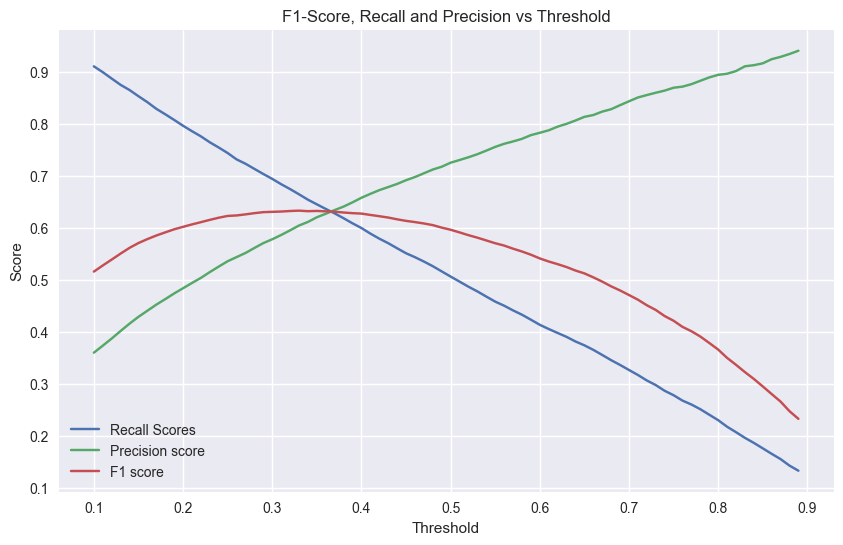

Max F1-Score: 0.633


In [1023]:
# Предсказания вероятностей для положительного класса

y_proba_test = cb_clf.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
recall_scores = []
precision_scores = []
f1_scores = []

for t in thresholds:
    y_pred_test = (y_proba_test >= t).astype(int)
    recall_sc = recall_score(y_test, y_pred_test)
    recall_scores.append(recall_sc)
    precision_sc = precision_score(y_test, y_pred_test)
    precision_scores.append(precision_sc)
    f1 = f1_score(y_test, y_pred_test)
    f1_scores.append(f1)
    

# Построим график

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(thresholds, recall_scores, label="Recall Scores")
plt.plot(thresholds, precision_scores, label="Precision score")
plt.plot(thresholds, f1_scores, label="F1 score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1-Score, Recall and Precision vs Threshold")
plt.grid(True)
plt.legend()
plt.show();

print(f'Max F1-Score: {round(max(f1_scores),3)}')

In [1026]:
# Создаём кросс-валидатор k-fold со стратификацией

skf = StratifiedKFold(n_splits=5)

# Делаем предсказание вероятностей на кросс-валидации

y_cv_proba_pred = cross_val_predict(cb_clf, X_resampled, y_resampled, cv=skf, method='predict_proba')

y_cv_proba_pred = y_cv_proba_pred[:, 1]

#Вычисляем координаты PR-кривой

precision, recall, thresholds = precision_recall_curve(y_resampled, y_cv_proba_pred)

print('Thresholds:', thresholds[:5])
print('Precision scores:', precision[:5])
print('Recall scores:', recall[:5])

Thresholds: [2.89398988e-06 1.07767107e-05 1.28238640e-05 1.31070719e-05
 1.50812927e-05]
Precision scores: [0.5        0.50000296 0.50000592 0.50000888 0.50001184]
Recall scores: [1. 1. 1. 1. 1.]


Best threshold = 0.52, F1-Score = 0.88


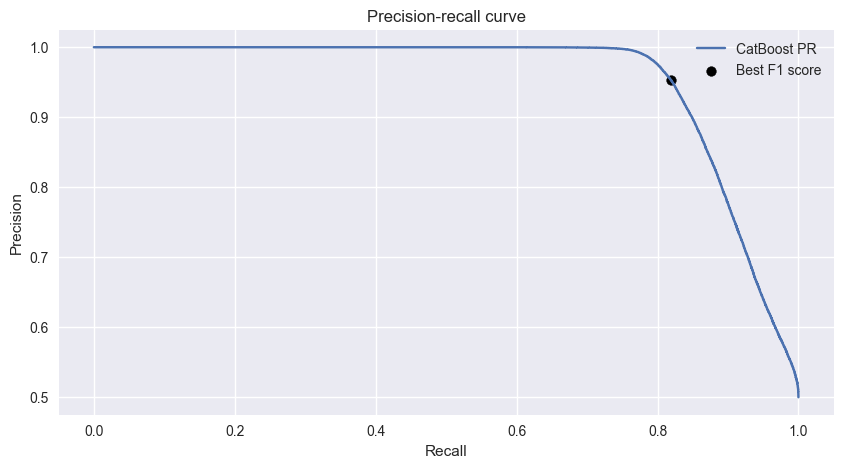

In [1027]:
# Вычисляем F1-меру при различных threshold

f1_scores = (2 * precision * recall) / (precision + recall)

# Определяем индекс максимума

idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

#Строим PR-кривую

fig, ax = plt.subplots(figsize=(10, 5)) 
#Строим линейный график зависимости precision от recall
ax.plot(recall, precision, label='CatBoost PR')
#Отмечаем точку максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Best F1 score')
#Даем графику название и подписи осям
ax.set_title('Precision-recall curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
#Отображаем легенду
ax.legend();

In [1028]:
# Получаем вероятности на тестовом наборе

y_test_proba = cb_clf.predict_proba(X_test_scaled)[:, 1]  # Вероятности для класса 1

# Применяем порог 0.52 (оптимальный для F1)

optimal_threshold = 0.52
y_pred_adjusted = (y_test_proba >= optimal_threshold).astype(int)

# Оцениваем результаты

print('Результаты для тестовой выборки с порогом 0.52:', '\n', classification_report(y_test, y_pred_adjusted))

Результаты для тестовой выборки с порогом 0.52: 
               precision    recall  f1-score   support

           0       0.89      0.96      0.93     41587
           1       0.74      0.49      0.59      9163

    accuracy                           0.88     50750
   macro avg       0.82      0.72      0.76     50750
weighted avg       0.87      0.88      0.87     50750



In [1029]:
# Применим порог в 0.63 для метрики Recall 

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
cb_clf.fit(X_resampled, y_resampled)

# Получаем вероятности на тестовом наборе

y_test_proba = cb_clf.predict_proba(X_test_scaled)[:, 1]  # Вероятности для класса 1

# Вычисляем PR-кривую для выбора порога

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Выбираем порог для recall ≥ 0.63 с максимальной precision

mask = recall >= 0.63
if mask.any():
    # Находим индекс последнего значения recall >= 0.63
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        last_valid_idx = valid_indices[-1]  # Берем последний индекс с recall >= 0.63
        optimal_threshold = thresholds[last_valid_idx] if last_valid_idx < len(thresholds) else thresholds[-1]
        optimal_precision = precision[last_valid_idx + 1]  # +1 из-за смещения
        optimal_recall = recall[last_valid_idx + 1]
        print(f"Оптимальный порог: {optimal_threshold:.2f}")
        print(f"Precision: {optimal_precision:.2f}, Recall: {optimal_recall:.2f}")
    else:
        print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог.")
        optimal_threshold = 0.5
else:
    print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог.")
    optimal_threshold = 0.5

# Применяем выбранный порог к предсказаниям

y_pred_adjusted = (y_test_proba >= optimal_threshold).astype(int)

# Оцениваем результаты

print('Результат с настроенным порогом >= 0.63:', '\n', classification_report(y_test, y_pred_adjusted))

Optimal threshold: 0.37
Precision: 0.63, Recall: 0.63
Результат с настроенным порогом >= 0.63: 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     41587
           1       0.63      0.63      0.63      9163

    accuracy                           0.87     50750
   macro avg       0.78      0.77      0.77     50750
weighted avg       0.87      0.87      0.87     50750



#### 5.8.3 Stacking

In [1030]:
# Настройка стекинга, обучаем модель

estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, solver='lbfgs', C=10, penalty='l2', max_iter=10000)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, criterion='entropy', max_depth=10, min_samples_split=3, min_samples_leaf=3)),
    ('cb', CatBoostClassifier(random_state=RANDOM_STATE, verbose=False))
]

# Используем логистическую регрессию в качестве финального классификатора

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    passthrough=True
)

st_clf.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = st_clf.predict(X_test_scaled)

print('Результаты для тестовой выборки', '\n', classification_report(y_test, y_pred_test))

Результаты для тестовой выборки 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     41587
           1       0.62      0.62      0.62      9163

    accuracy                           0.86     50750
   macro avg       0.77      0.77      0.77     50750
weighted avg       0.86      0.86      0.86     50750



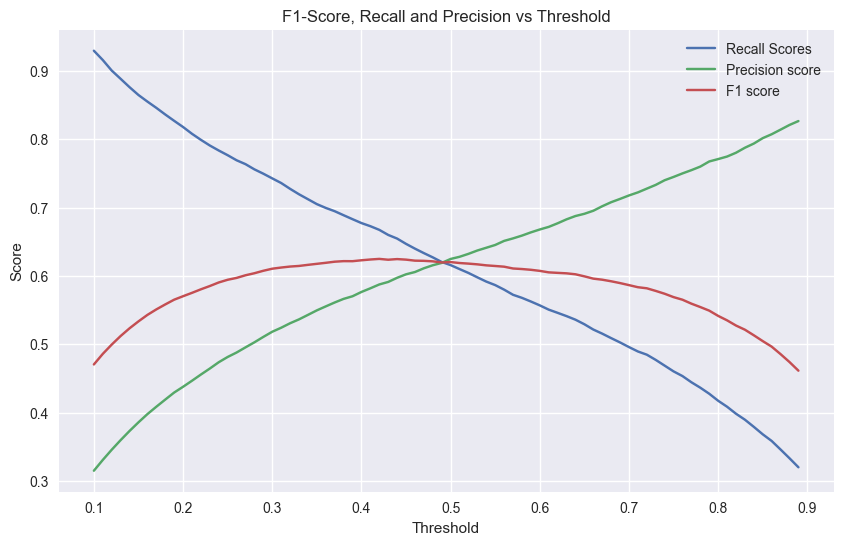

Max F1-Score: 0.625


In [1031]:
# Предсказания вероятностей для положительного класса

y_proba_test = st_clf.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
recall_scores = []
precision_scores = []
f1_scores = []

for t in thresholds:
    y_pred_test = (y_proba_test >= t).astype(int)
    recall_sc = recall_score(y_test, y_pred_test)
    recall_scores.append(recall_sc)
    precision_sc = precision_score(y_test, y_pred_test)
    precision_scores.append(precision_sc)
    f1 = f1_score(y_test, y_pred_test)
    f1_scores.append(f1)
    

# Построим график

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(thresholds, recall_scores, label="Recall Scores")
plt.plot(thresholds, precision_scores, label="Precision score")
plt.plot(thresholds, f1_scores, label="F1 score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1-Score, Recall and Precision vs Threshold")
plt.grid(True)
plt.legend()
plt.show();

print(f'Max F1-Score: {round(max(f1_scores),3)}')

In [1032]:
skf = StratifiedKFold(n_splits=3)

#Делаем предсказание вероятностей на кросс-валидации

y_cv_proba_pred = cross_val_predict(st_clf, X_resampled, y_resampled, cv=skf, method='predict_proba')

y_cv_proba_pred = y_cv_proba_pred[:, 1]

#Вычисляем координаты PR-кривой

precision, recall, thresholds = precision_recall_curve(y_resampled, y_cv_proba_pred)

print('Thresholds:', thresholds[:5])
print('Precision scores:', precision[:5])
print('Recall scores:', recall[:5])

Thresholds: [1.61409026e-07 1.08989337e-05 1.09649581e-05 2.02028832e-05
 3.68482075e-05]
Precision scores: [0.5        0.50000296 0.50000592 0.50000888 0.50001184]
Recall scores: [1. 1. 1. 1. 1.]


Best threshold = 0.82, F1-Score = 0.87


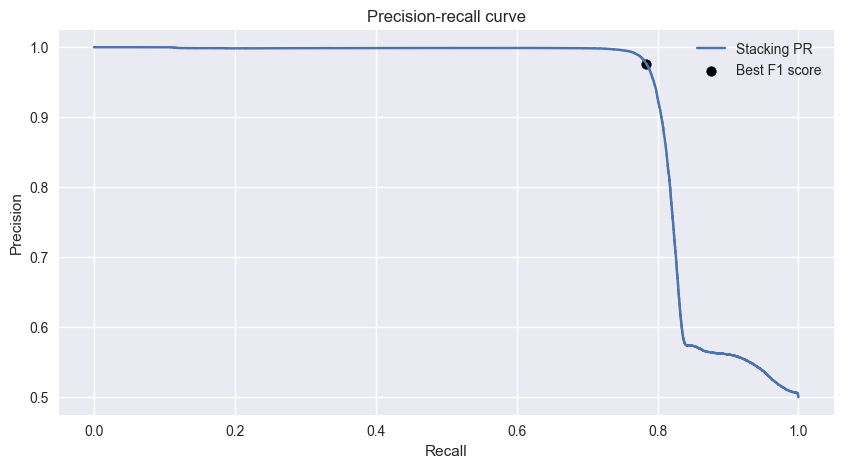

In [1033]:
#Вычисляем F1-меру при различных threshold

f1_scores = (2 * precision * recall) / (precision + recall)

#Определяем индекс максимума

idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

#Строим PR-кривую

fig, ax = plt.subplots(figsize=(10, 5)) 
#Строим линейный график зависимости precision от recall
ax.plot(recall, precision, label='Stacking PR')
#Отмечаем точку максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Best F1 score')
#Даем графику название и подписи осям
ax.set_title('Precision-recall curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
#Отображаем легенду
ax.legend();

In [1034]:
# Получаем вероятности на тестовом наборе

y_test_proba = st_clf.predict_proba(X_test_scaled)[:, 1]

# Вычисляем PR-кривую для выбора порога

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Выбираем порог для recall ≥ 0.63 с максимальной precision

mask = recall >= 0.63
if mask.any():
    # Находим индекс последнего значения recall >= 0.63
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        last_valid_idx = valid_indices[-1]  # Берем последний индекс с recall >= 0.63
        optimal_threshold = thresholds[last_valid_idx] if last_valid_idx < len(thresholds) else thresholds[-1]
        optimal_precision = precision[last_valid_idx + 1]  # +1 из-за смещения
        optimal_recall = recall[last_valid_idx + 1]
        print(f"Оптимальный порог: {optimal_threshold:.2f}")
        print(f"Precision: {optimal_precision:.2f}, Recall: {optimal_recall:.2f}")
    else:
        print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
        optimal_threshold = 0.5
else:
    print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
    optimal_threshold = 0.5

# Применяем выбранный порог к предсказаниям

y_pred_adjusted = (y_test_proba >= optimal_threshold).astype(int)

# Оцениваем результаты

print('Результат с настроенным порогом >= 0.63:', '\n', classification_report(y_test, y_pred_adjusted))

Оптимальный порог: 0.48
Precision: 0.61, Recall: 0.63
Результат с настроенным порогом >= 0.63: 
               precision    recall  f1-score   support

           0       0.92      0.91      0.92     41587
           1       0.61      0.63      0.62      9163

    accuracy                           0.86     50750
   macro avg       0.77      0.77      0.77     50750
weighted avg       0.86      0.86      0.86     50750



#### 5.8.3 Voting Classifier

In [1035]:
# Настроим голосующий ансамбль, и затем настроим эту модель

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
xgb_clf = XGBClassifier(random_state=RANDOM_STATE)
lgb_clf = LGBMClassifier(random_state=RANDOM_STATE)

ensemble = VotingClassifier(estimators=[
    ('catboost', cb_clf),
    ('xgboost', xgb_clf),
    ('lightgbm', lgb_clf)
], voting='soft')

ensemble.fit(X_resampled, y_resampled)

# Делаем предсказания на тестовой выборке

y_pred_test = ensemble.predict(X_test_scaled)

print('Результаты для тестовой выборки:', '\n', classification_report(y_test, y_pred_test))

[LightGBM] [Info] Number of positive: 84432, number of negative: 84432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9347
[LightGBM] [Info] Number of data points in the train set: 168864, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Результаты для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92     41587
           1       0.70      0.50      0.59      9163

    accuracy                           0.87     50750
   macro avg       0.80      0.73      0.76     50750
weighted avg       0.86      0.87      0.86     50750



c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


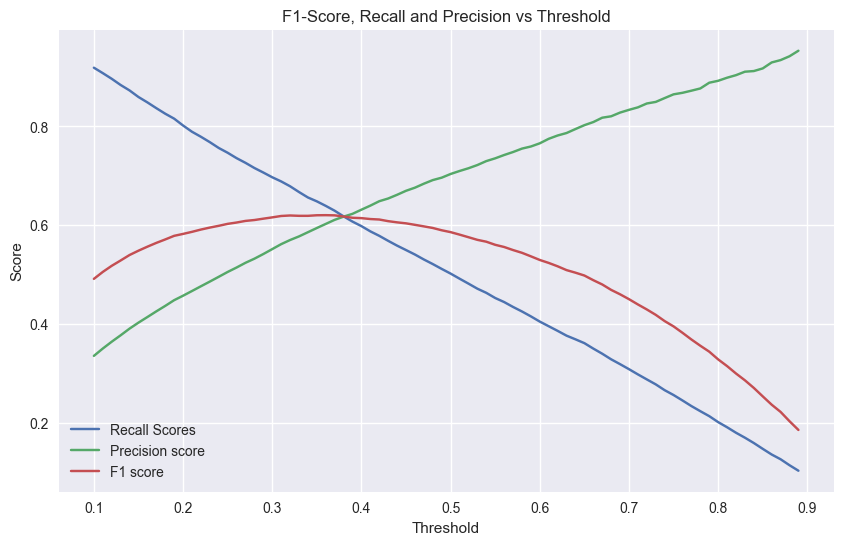

Max F1-Score: 0.62


In [1036]:
# Предсказания вероятностей для положительного класса

y_proba_test = ensemble.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
recall_scores = []
precision_scores = []
f1_scores = []

for t in thresholds:
    y_pred_test = (y_proba_test >= t).astype(int)
    recall_sc = recall_score(y_test, y_pred_test)
    recall_scores.append(recall_sc)
    precision_sc = precision_score(y_test, y_pred_test)
    precision_scores.append(precision_sc)
    f1 = f1_score(y_test, y_pred_test)
    f1_scores.append(f1)
    

# Построим график

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(thresholds, recall_scores, label="Recall Scores")
plt.plot(thresholds, precision_scores, label="Precision score")
plt.plot(thresholds, f1_scores, label="F1 score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1-Score, Recall and Precision vs Threshold")
plt.grid(True)
plt.legend()
plt.show();

print(f'Max F1-Score: {round(max(f1_scores),3)}')

In [1037]:
skf = StratifiedKFold(n_splits=3)

#Делаем предсказание вероятностей на кросс-валидации

y_cv_proba_pred = cross_val_predict(ensemble, X_resampled, y_resampled, cv=skf, method='predict_proba')

y_cv_proba_pred = y_cv_proba_pred[:, 1]

#Вычисляем координаты PR-кривой

precision, recall, thresholds = precision_recall_curve(y_resampled, y_cv_proba_pred)

print('Thresholds:', thresholds[:5])
print('Precision scores:', precision[:5])
print('Recall scores:', recall[:5])

[LightGBM] [Info] Number of positive: 56288, number of negative: 56288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9317
[LightGBM] [Info] Number of data points in the train set: 112576, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 56288, number of negative: 56288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8636
[LightGBM] [Info] Number of data points in the train set: 112576, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 56288, number of negative: 56288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8662
[LightGBM] [Info] Number of data points in the train set: 112576, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Thresholds: [0.00031384 0.00032591 0.0003295  0.0003373  0.00035793]
Precision scores: [0.5        0.50000296 0.50000592 0.50000888 0.50001184]
Recall scores: [1. 1. 1. 1. 1.]


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold = 0.57, F1-Score = 0.86


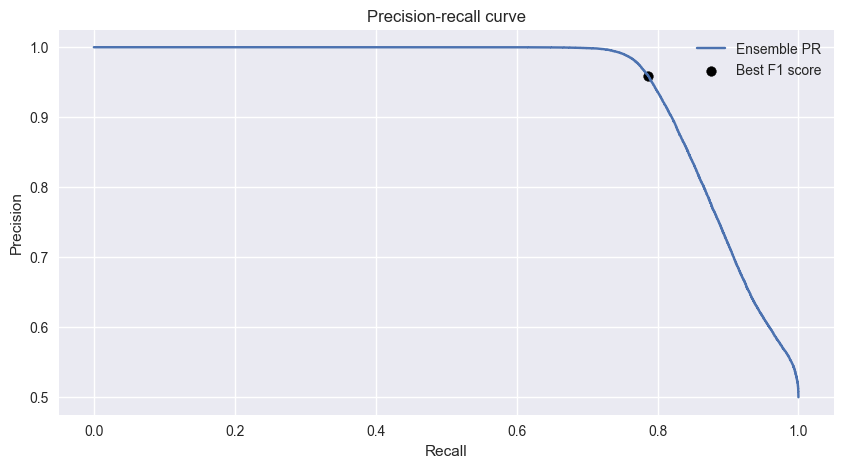

In [1038]:
#Вычисляем F1-меру при различных threshold

f1_scores = (2 * precision * recall) / (precision + recall)

#Определяем индекс максимума

idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

#Строим PR-кривую
fig, ax = plt.subplots(figsize=(10, 5)) 
#Строим линейный график зависимости precision от recall
ax.plot(recall, precision, label='Ensemble PR')
#Отмечаем точку максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Best F1 score')
#Даем графику название и подписи осям
ax.set_title('Precision-recall curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
#Отображаем легенду
ax.legend();

In [1039]:
# Получаем вероятности на тестовом наборе

y_test_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

# Вычисляем PR-кривую для выбора порога

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Выбираем порог для recall ≥ 0.63 с максимальной precision
mask = recall >= 0.63
if mask.any():
    # Находим индекс последнего значения recall >= 0.63
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        last_valid_idx = valid_indices[-1]  # Берем последний индекс с recall >= 0.63
        optimal_threshold = thresholds[last_valid_idx] if last_valid_idx < len(thresholds) else thresholds[-1]
        optimal_precision = precision[last_valid_idx + 1]  # +1 из-за смещения
        optimal_recall = recall[last_valid_idx + 1]
        print(f"Оптимальный порог: {optimal_threshold:.2f}")
        print(f"Precision: {optimal_precision:.2f}, Recall: {optimal_recall:.2f}")
    else:
        print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
        optimal_threshold = 0.5
else:
    print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
    optimal_threshold = 0.5

# Применяем выбранный порог к предсказаниям

y_pred_adjusted = (y_test_proba >= optimal_threshold).astype(int)

# Оцениваем результаты

print('Результат с настроенным порогом >= 0.63:', '\n', classification_report(y_test, y_pred_adjusted))

Оптимальный порог: 0.37
Precision: 0.61, Recall: 0.63
Результат с настроенным порогом >= 0.63: 
               precision    recall  f1-score   support

           0       0.92      0.91      0.91     41587
           1       0.61      0.63      0.62      9163

    accuracy                           0.86     50750
   macro avg       0.76      0.77      0.77     50750
weighted avg       0.86      0.86      0.86     50750



c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Подведем вывод, после финальной настройки самой лучшей моделью оказался алгоритм `CatBoost Classifier`. 
Финальные результаты для класса 1 :

          Class   precision  recall  f1-score   

           0       0.92      0.92      0.92
           1       0.63      0.63      0.63

     weighted avg  0.86      0.86      0.86


### 5.9 Оценка Модели

In [1044]:
# Обучим CatBoostClassifier на сбалансированной выборке, параметры по умолчанию

cb_clf = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False)
cb_clf.fit(X_resampled, y_resampled)

# Получаем вероятности на тестовом наборе

y_test_proba = cb_clf.predict_proba(X_test_scaled)[:, 1] 

# Вычисляем PR-кривую для выбора порога

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Выбираем порог для recall ≥ 0.63 с максимальной precision
mask = recall >= 0.63
if mask.any():
    # Находим индекс последнего значения recall >= 0.63
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        last_valid_idx = valid_indices[-1]  # Берем последний индекс с recall >= 0.63
        optimal_threshold = thresholds[last_valid_idx] if last_valid_idx < len(thresholds) else thresholds[-1]
        optimal_precision = precision[last_valid_idx + 1]  # +1 из-за смещения
        optimal_recall = recall[last_valid_idx + 1]
        print(f"Оптимальный порог: {optimal_threshold:.2f}")
        print(f"Precision: {optimal_precision:.2f}, Recall: {optimal_recall:.2f}")
    else:
        print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
        optimal_threshold = 0.5
else:
    print("Не найдено заданых значений порога >= 0.63. Используем стандартный порог")
    optimal_threshold = 0.5

# Применяем выбранный порог к предсказаниям

y_pred_adjusted = (y_test_proba >= optimal_threshold).astype(int)

# Оцениваем результаты

print('Результат с настроенным порогом >= 0.63:', '\n', classification_report(y_test, y_pred_adjusted))

Оптимальный порог: 0.37
Precision: 0.63, Recall: 0.63
Результат с настроенным порогом >= 0.63: 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     41587
           1       0.63      0.63      0.63      9163

    accuracy                           0.87     50750
   macro avg       0.78      0.77      0.77     50750
weighted avg       0.87      0.87      0.87     50750



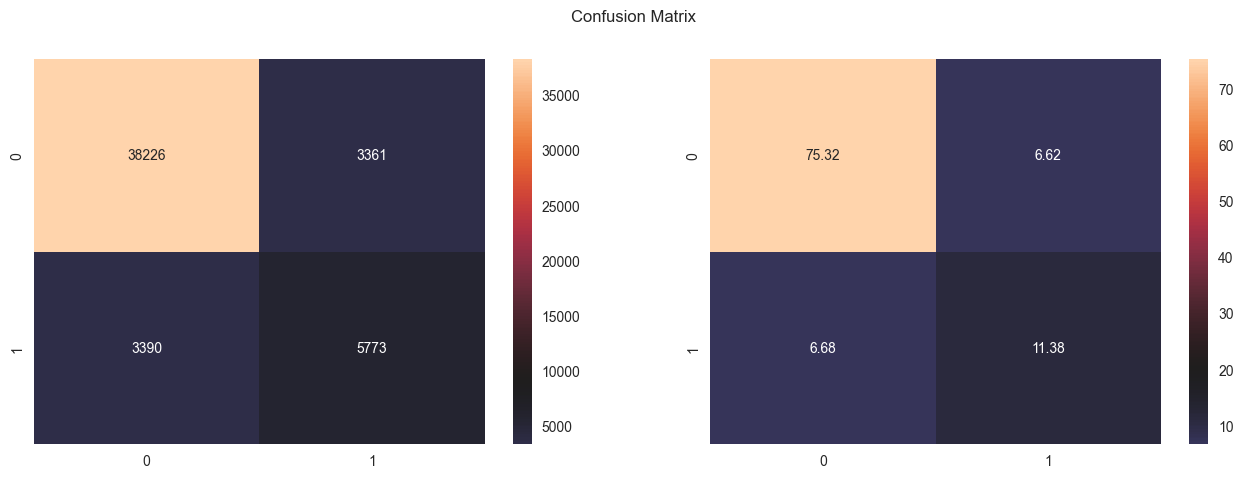

In [1045]:
# Вычисляем матрицу ошибок для предсказаний с порогом

conf_matrix = confusion_matrix(y_test, y_pred_adjusted)
conf_percent = conf_matrix / conf_matrix.sum() * 100

# Визуализация

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
sns.heatmap(conf_matrix, annot=True, fmt='.0f', center=9000, ax=ax[0])
sns.heatmap(np.round(conf_percent, 2), annot=True, fmt='.2f', center=20, ax=ax[1])
fig.suptitle('Confusion Matrix', fontsize=12)
plt.show();

In [1046]:
# Определяем метрики для оценки

scoring = {
 'accuracy': 'accuracy',
 'precision': make_scorer(precision_score, average='weighted'),
 'recall': make_scorer(recall_score, average='weighted'),
 'f1': make_scorer(f1_score, average='weighted')
}

# Выполняем кросс-валидацию

cv_results = cross_validate(
 cb_clf,
 X_resampled,
 y_resampled,
 cv=5, 
 scoring=scoring,
 return_train_score=False,
 n_jobs=-1 
)

# Выводим средние значения и стандартное отклонение для каждой метрики

print("Результаты кросс-валидации (5 фолдов):")
print(f"Accuracy: {np.mean(cv_results['test_accuracy']):.2f} ± {np.std(cv_results['test_accuracy']):.2f}")
print(f"Precision (weighted): {np.mean(cv_results['test_precision']):.2f} ± {np.std(cv_results['test_precision']):.2f}")
print(f"Recall (weighted): {np.mean(cv_results['test_recall']):.2f} ± {np.std(cv_results['test_recall']):.2f}")
print(f"F1-score (weighted): {np.mean(cv_results['test_f1']):.2f} ± {np.std(cv_results['test_f1']):.2f}")

Результаты кросс-валидации (5 фолдов):
Accuracy: 0.89 ± 0.15
Precision (weighted): 0.93 ± 0.08
Recall (weighted): 0.89 ± 0.15
F1-score (weighted): 0.87 ± 0.19


#### 📊 Итоговый отчёт поcле обучени модели

### 🧠 Используем модель

- **Модель:** CatBoostClassifier (по умолчанию)
- **Выборка:** сбалансированная (после применения ресемплинга), без применения PCA, без ограничения признаков
- **Целевая метрика:** компромисс Precision и Recall с приоритетом Recall ~ 0.63

---

### ⚙️ Оптимизация порога классификации

- **Выбран порог:** `optimal_threshold ≈ 0.37`
- **Достигнутые метрики:**
  - **Precision:** `63%`
  - **Recall:** `63%`
  - **F1-Score:** `63%`

---

### 🔍 Анализ матрицы ошибок

#### Абсолютные значения:
|                      | **Предсказано: 0** | **Предсказано: 1** |
|----------------------|--------------------|--------------------|
| **Факт: 0 (TN / FP)**| 38 226             | 3 361              |
| **Факт: 1 (FN / TP)**| 3 390              | 5 773              |

#### Относительные значения (в процентах от общего количества):
|                      | **Предсказано: 0** | **Предсказано: 1** |
|----------------------|--------------------|--------------------|
| **Факт: 0**          | 75.32 %            | 6.62 %             |
| **Факт: 1**          | 6.68 %             | 11.38 %            |

---

### 📈 Интерпретация

- **True Negative (TN = 38 226)** — большинство объектов класса 0 распознаны правильно.
- **False Positive (FP = 3 361)** — около **6.62 %** примеров ошибочно отнесены к положительному классу.
- **True Positive (TP = 5 773)** — модель успешно распознала **11.38 %** всех объектов как положительные.
- **False Negative (FN = 3 390)** — около **6.68 %** объектов положительного класса не были распознаны моделью.

---

### 🧮 Вывод

- Модель демонстрирует **сбалансированное поведение**: количество ложноположительных и ложноотрицательных случаев близко, что говорит о стабильной классификации.
- **Recall ≈ 63 %** — Максимальное значение, которое нам удалось достичь.
- **Precision ≈ 63%** - Компромисс, чтобы повысить качество модели
- Относительно **низкое количество FP** говорит о том, что модель не склонна к завышенной тревожности (избыточной классификации как "1").

---

### 🔁 Кросс-валидация (5 фолдов)

| Метрика                | Среднее значение | Стандартное отклонение |
| ---------------------- | ---------------- | ---------------------- |
| **Accuracy**           | 0.89             | ± 0.15                 |
| **Precision (взвеш.)** | 0.93             | ± 0.08                 |
| **Recall (взвеш.)**    | 0.89             | ± 0.15                 |
| **F1-score (взвеш.)**  | 0.87             | ± 0.19                 |

---

### 📊 Сравнение результатов: Baseline vs Финальная модель

| Метрика            | Класс | Baseline модель | Финальная модель |
|--------------------|-------|------------------|------------------|
| **Precision**      | 0     | 0.84             | 0.92             |
|                    | 1     | 0.61             | 0.63             |
| **Recall**         | 0     | 0.98             | 0.92             |
|                    | 1     | 0.16             | 0.63             |
| **F1-score**       | 0     | 0.90             | 0.92             |
|                    | 1     | 0.25             | 0.63             |
| **Accuracy**       | —     | 0.83             | 0.87             |
| **Macro Avg**      | —     | 0.72 / 0.57 / 0.58 | 0.78 / 0.77 / 0.77 |
| **Weighted Avg**   | —     | 0.80 / 0.83 / 0.79 | 0.87 / 0.87 / 0.87 |

---

### 💡 Комментарии

- ✅ **Precision и Recall для класса 1** значительно улучшены:
  - Recall вырос с **0.16 до 0.63** 
  - Precision для класса 1 также увеличился.

- ⚖️ **Баланс между классами стал лучше**: macro average вырос на всех трёх метриках.

- 🎯 **F1-score для класса 1** вырос более чем в **2.5 раза** — с 0.25 до 0.63, что говорит об общей сбалансированности метрик precision и recall.

- 📈 **Общая точность (Accuracy)** улучшилась с **0.83 до 0.87**, несмотря на приоритет положительного класса.

---

### ✅ Вывод

Финальная модель с подобранным порогом показывает значительный прирост качества в отношении распознавания положительного класса **без ухудшения метрик по отрицательному классу**. Это делает её значительно более пригодной для использования в задачах с дисбалансом классов.



## 6. Deployment

**Объединим все функции в общие, чтобы собрать все процессы обработки данных в единный пайплайн**

In [ ]:
# Создадим обобщаяющую функцию, которая будет предобрабатывать признаки

def preprocess_data(df):
    
    """Функция для предобработки данных"""
    
    df = update_category(df)
    df = update_price_category(df)
    df = update_product_line(df)
    df = update_product_type(df)
    df = update_shape(df)
    df = update_season(df)
    df['Actual_Price'] = df['Actual_Price'].apply(update_price)
    df['Main_Fabric'] = df['Product_Composition'].apply(extract_main_fabric)
    df = add_datetime_features(df) 

    return df

In [1260]:
# Создадим обобщаяющую функцию, которая будет трансформировать признаки

def transform_data(df):
    
    """Функция для трансформации данных и создания новых признаков"""
    
    df = stock_preprocessing(df)
    df = apply_all_ratios(df)
    df = color_preprocessing(df)
    df = main_fabric_preprocessing(df)
    df = category_preprocessing(df)
    df = price_preprocessing(df)
    df = shape_preprocessing(df)
    df = city_preprocessing(df)
    df = add_cluster_to_data(df)
    
    return df

In [1277]:
# Создадим обобщаяющую функцию, которая будет очищать данные

def clean_data(df):
    
    """Функция для очистки данных"""
    
    # Удалим ненужные столбцы из датасета

    data_to_drop = [
        'StatusProductSmartphone', 'Fashion_Level', 'city', 'time', 'Year', 'Store_id', 
        'Product_id', 'StockinTransitU', 'StockInProgressU', 'Date', 'First_Allocation_Date',
        'Days_in_Store', 'Country', 'Product_Composition']
    clean_df = df.drop(data_to_drop, axis=1)
    
    #clean_df = remove_multicollinear_features(clean_df, threshold=0.8)
    return clean_df
        

In [ ]:
# Создадим класс для кодирования признаков, который будет сохранять состояние кодировщиков и использовать их для трансформации новых данных

class PersistentEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, save_path="data/preprocessing_state"):
        self.threshold = threshold
        self.save_path = save_path
        self.label_encoders = {}
        self.binary_encoder = None
        self.dummies_columns = []
        self.columns_to_keep = []

    def fit(self, X, y=None):
        X = X.copy()
        
        # Label Encoding
        self.label_columns = ['Product_Line', 'Product_Type', 'Color_info', 'Category', 'City', 'Store_Name', 'Main_Fabric']
        for col in self.label_columns:
            le = LabelEncoder()
            X[col] = X[col].astype(str)
            le.fit(X[col])
            self.label_encoders[col] = le
            X[col] = le.transform(X[col])
        
        # Binary Encoding
        binary_cols = ['Product_Shape']
        self.binary_encoder = ce.BinaryEncoder(cols=binary_cols)
        binary_encoded = self.binary_encoder.fit_transform(X[binary_cols])
        X = X.drop(columns=binary_cols).reset_index(drop=True)
        X = pd.concat([X, binary_encoded], axis=1)
        
        # Dummies Encoding
        dummy_cols = ['StatusSale', 'IsReplenBlocked', 'Price_Category', 'Method', 'Current_Season', 'Price_Status']
        dummies = pd.get_dummies(X[dummy_cols], prefix=dummy_cols, prefix_sep='_', dtype='int')
        X = X.drop(columns=dummy_cols)
        X = pd.concat([X, dummies], axis=1)
        self.dummies_columns = dummies.columns.tolist()
        
        # Очищение от мультикорреляции
        corr_matrix = X.corr().abs()
        upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > self.threshold)]
        X = X.drop(columns=self.to_drop)
        
        # Сохраняем итоговый список признаков
        self.columns_to_keep = X.columns.tolist()

        return self

    def transform(self, X):
        X = X.copy()
        
        # Label Encoding
        for col, le in self.label_encoders.items():
            X[col] = X[col].astype(str)
            X[col] = X[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

        # Binary Encoding
        binary_encoded = self.binary_encoder.transform(X[['Product_Shape']])
        X = X.drop(columns=['Product_Shape'])
        X = pd.concat([X, binary_encoded], axis=1)
        
        # Dummies Encoding
        dummy_cols = ['StatusSale', 'IsReplenBlocked', 'Price_Category', 'Method', 'Current_Season', 'Price_Status']
        dummies = pd.get_dummies(X[dummy_cols], prefix=dummy_cols, prefix_sep='_', dtype='int')
        X = X.drop(columns=dummy_cols)
        
        # Добавляем недостающие столбцы
        for col in self.dummies_columns:
            if col not in dummies.columns:
                dummies[col] = 0
        dummies = dummies[self.dummies_columns]
        X = pd.concat([X, dummies], axis=1)

        # Удаляем признаки с сильной мультикорреляцией
        X = X.drop(columns=[col for col in self.to_drop if col in X.columns], errors='ignore')
        
        # Делаем подгонку к финальному набору признаков
        for col in self.columns_to_keep:
            if col not in X.columns:
                X[col] = 0
        X = X[self.columns_to_keep]
        
        return X


In [ ]:
# Создадим класс для классификатора с порогом

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_recall=0.63, random_state=42):
        self.threshold_recall = threshold_recall
        self.random_state = random_state
        self.model = CatBoostClassifier(verbose=False, random_state=self.random_state)
        self.optimal_threshold = 0.5

    def fit(self, X, y):
        self.model.fit(X, y)
        y_proba = self.model.predict_proba(X)[:, 1]
        
        precision, recall, thresholds = precision_recall_curve(y, y_proba)
        mask = recall >= self.threshold_recall
        
        if mask.any():
            last_valid_idx = np.where(mask)[0][-1]
            if last_valid_idx < len(thresholds):
                self.optimal_threshold = thresholds[last_valid_idx]
            else:
                self.optimal_threshold = thresholds[-1]
        else:
            self.optimal_threshold = 0.5
            
        return self

    def predict(self, X):
        y_proba = self.model.predict_proba(X)[:, 1]
        return (y_proba >= self.optimal_threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def get_threshold(self):
        return self.optimal_threshold

In [ ]:
# Создадим класс для предобработки данных, который будет использоваться в пайплайне

class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, cities=None, weather=None, product=None):
        self.cities = cities
        self.weather = weather
        self.product = product

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        #print("Начало:", X.shape)

        df = merge_datasets(X, self.cities, self.weather, self.product)
        #print("После merge:", df.shape)

        df = preprocess_data(df)
        #print("После preprocess_data:", df.shape)

        df = transform_data(df)
        #print("После transform_data:", df.shape)

        #df = encode_data(df)
        #print("После encode_data:", df.shape)

        clean_df = clean_data(df)
        #print("После clean_data:", clean_df.shape)

        return clean_df

In [ ]:
# Строим Pipeline

pipeline = Pipeline(steps=[
    ("custom_preprocessor", CustomPreprocessor(
        cities=cities_data,
        weather=weather_data,
        product=product_data
    )),
    ("encoder", PersistentEncoderTransformer(threshold=0.8)),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", CatBoostClassifier(verbose=False, random_state=42))
])


In [ ]:
# Загружаем данные и разделяем на обучающую и тестовую выборки

data = pd.read_csv('data/train.csv')
data = data.drop_duplicates()

X = data.drop('Is_Bestseller', axis=1)
y = data['Is_Bestseller']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)

In [1275]:
# Проверяем размерности данных

X_train.shape, y_train.shape

((102775, 17), (102775,))

In [1286]:
# Обучаем пайплайн на тренировочных данных

pipeline.fit(X_train, y_train)

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Pipeline(steps=[('custom_preprocessor',
                 CustomPreprocessor(cities=    Store_id  Country                  City Store_Name
0        185  Romania             BUCHAREST       PH07
1        193  Romania             TIMISOARA       PH09
2        195  Romania             CONSTANTA       PH10
3        198  Romania             BUCHAREST       PH11
4        199  Romania               CRAIOVA       PH12
5        216  Romania                GALATI       PH13
6        227  Romania        RAMNICU VALCEA       PH14
7        236  Romania                 SIBIU       PH15
8        256  Romania             BALOTESTI       PH16
9        276  Romania                  IASI       PH17
10       278  Romania             TIMISOARA       PH22
1...
13369   7425  2025-05-29   TIMISOARA  15.9    15.10
13370   7426  2025-05-30   TIMISOARA  16.4    15.11
13371   7427  2025-05-31   TIMISOARA  17.2    15.97
13372   7428  2025-06-01   TIMISOARA  19.6    17.00
13373   7429  2025-06-02   TIMISOARA  22.6    17.94

[13374 rows x 5 columns])),
                ('encoder', PersistentEncoderTransformer()),
                ('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x0000015D350402C0>)])

In [1287]:
# Загрузим тестовые данные для теста

test_data = pd.read_csv('data/test_sample.csv')

# Применяем пайплайн к тестовым данным

y_pred = pipeline.predict(test_data)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [1288]:
# Сохранение модели

joblib.dump(pipeline, 'data/models/CatBoostClassifier_bestseller_pipeline.pkl')

['data/models/CatBoostClassifier_bestseller_pipeline.pkl']